# Global Temparature Analysis
## Analysis of Temparature with country and major city
### By Utsav Chatterjee


In [1]:
# === Spark Setup ===

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("GlobalTemperatureAnalysis")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .getOrCreate()
)

spark


25/11/30 12:56:09 WARN Utils: Your hostname, UTSAV-LAPTOP resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/11/30 12:56:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/30 12:56:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/30 12:56:10 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## Load the CSVs

In [5]:
df_global = spark.read.csv("GlobalTemperatures.csv", header=True, inferSchema=True)
df_country = spark.read.csv("GlobalLandTemperaturesByCountry.csv", header=True, inferSchema=True)
df_city = spark.read.csv("GlobalLandTemperaturesByMajorCity.csv", header=True, inferSchema=True)


In [6]:
df_global.printSchema()
df_country.printSchema()
df_city.printSchema()


root
 |-- dt: date (nullable = true)
 |-- LandAverageTemperature: double (nullable = true)
 |-- LandAverageTemperatureUncertainty: double (nullable = true)
 |-- LandMaxTemperature: double (nullable = true)
 |-- LandMaxTemperatureUncertainty: double (nullable = true)
 |-- LandMinTemperature: double (nullable = true)
 |-- LandMinTemperatureUncertainty: double (nullable = true)
 |-- LandAndOceanAverageTemperature: double (nullable = true)
 |-- LandAndOceanAverageTemperatureUncertainty: double (nullable = true)

root
 |-- dt: date (nullable = true)
 |-- AverageTemperature: double (nullable = true)
 |-- AverageTemperatureUncertainty: double (nullable = true)
 |-- Country: string (nullable = true)

root
 |-- dt: date (nullable = true)
 |-- AverageTemperature: double (nullable = true)
 |-- AverageTemperatureUncertainty: double (nullable = true)
 |-- City: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = 

In [7]:
df_global.show(5)


+----------+----------------------+---------------------------------+------------------+-----------------------------+------------------+-----------------------------+------------------------------+-----------------------------------------+
|        dt|LandAverageTemperature|LandAverageTemperatureUncertainty|LandMaxTemperature|LandMaxTemperatureUncertainty|LandMinTemperature|LandMinTemperatureUncertainty|LandAndOceanAverageTemperature|LandAndOceanAverageTemperatureUncertainty|
+----------+----------------------+---------------------------------+------------------+-----------------------------+------------------+-----------------------------+------------------------------+-----------------------------------------+
|1750-01-01|    3.0340000000000003|                            3.574|              NULL|                         NULL|              NULL|                         NULL|                          NULL|                                     NULL|
|1750-02-01|                 3.083| 

In [8]:
df_country.show(5)

+----------+------------------+-----------------------------+-------+
|        dt|AverageTemperature|AverageTemperatureUncertainty|Country|
+----------+------------------+-----------------------------+-------+
|1743-11-01|4.3839999999999995|                        2.294|  Åland|
|1743-12-01|              NULL|                         NULL|  Åland|
|1744-01-01|              NULL|                         NULL|  Åland|
|1744-02-01|              NULL|                         NULL|  Åland|
|1744-03-01|              NULL|                         NULL|  Åland|
+----------+------------------+-----------------------------+-------+
only showing top 5 rows



In [9]:
df_city.show(5)

+----------+------------------+-----------------------------+-------+-------------+--------+---------+
|        dt|AverageTemperature|AverageTemperatureUncertainty|   City|      Country|Latitude|Longitude|
+----------+------------------+-----------------------------+-------+-------------+--------+---------+
|1849-01-01|            26.704|                        1.435|Abidjan|Côte D'Ivoire|   5.63N|    3.23W|
|1849-02-01|            27.434|                        1.362|Abidjan|Côte D'Ivoire|   5.63N|    3.23W|
|1849-03-01|            28.101|                        1.612|Abidjan|Côte D'Ivoire|   5.63N|    3.23W|
|1849-04-01|             26.14|           1.3869999999999998|Abidjan|Côte D'Ivoire|   5.63N|    3.23W|
|1849-05-01|            25.427|                          1.2|Abidjan|Côte D'Ivoire|   5.63N|    3.23W|
+----------+------------------+-----------------------------+-------+-------------+--------+---------+
only showing top 5 rows



## Checking Missing Values for each

In [10]:
# Missing value count for df_global
from pyspark.sql.functions import col, sum as spark_sum, when

missing_global = df_global.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_global.columns
])

missing_global.show(truncate=False)


+---+----------------------+---------------------------------+------------------+-----------------------------+------------------+-----------------------------+------------------------------+-----------------------------------------+
|dt |LandAverageTemperature|LandAverageTemperatureUncertainty|LandMaxTemperature|LandMaxTemperatureUncertainty|LandMinTemperature|LandMinTemperatureUncertainty|LandAndOceanAverageTemperature|LandAndOceanAverageTemperatureUncertainty|
+---+----------------------+---------------------------------+------------------+-----------------------------+------------------+-----------------------------+------------------------------+-----------------------------------------+
|0  |12                    |12                               |1200              |1200                         |1200              |1200                         |1200                          |1200                                     |
+---+----------------------+---------------------------------+--

In [11]:
df_global.describe().show()


25/11/27 00:57:50 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+----------------------+---------------------------------+------------------+-----------------------------+------------------+-----------------------------+------------------------------+-----------------------------------------+
|summary|LandAverageTemperature|LandAverageTemperatureUncertainty|LandMaxTemperature|LandMaxTemperatureUncertainty|LandMinTemperature|LandMinTemperatureUncertainty|LandAndOceanAverageTemperature|LandAndOceanAverageTemperatureUncertainty|
+-------+----------------------+---------------------------------+------------------+-----------------------------+------------------+-----------------------------+------------------------------+-----------------------------------------+
|  count|                  3180|                             3180|              1992|                         1992|              1992|                         1992|                          1992|                                     1992|
|   mean|     8.374731132075466|               0

In [12]:
# Missing Values in df_city
missing_city = df_city.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_city.columns
])

missing_city.show(truncate=False)


+---+------------------+-----------------------------+----+-------+--------+---------+
|dt |AverageTemperature|AverageTemperatureUncertainty|City|Country|Latitude|Longitude|
+---+------------------+-----------------------------+----+-------+--------+---------+
|0  |11002             |11002                        |0   |0      |0       |0        |
+---+------------------+-----------------------------+----+-------+--------+---------+



In [13]:
df_city.describe().show()

[Stage 18:=============================>                            (2 + 2) / 4]

+-------+------------------+-----------------------------+-------+-----------+--------+---------+
|summary|AverageTemperature|AverageTemperatureUncertainty|   City|    Country|Latitude|Longitude|
+-------+------------------+-----------------------------+-------+-----------+--------+---------+
|  count|            228175|                       228175| 239177|     239177|  239177|   239177|
|   mean|18.125968852854175|           0.9693434381505347|   NULL|       NULL|    NULL|     NULL|
| stddev| 10.02479971048484|            0.979643911437092|   NULL|       NULL|    NULL|     NULL|
|    min|           -26.772|                         0.04|Abidjan|Afghanistan|   0.80N|    0.00W|
|    max|            38.283|                       14.037|   Xian|   Zimbabwe|   8.84S|   99.91E|
+-------+------------------+-----------------------------+-------+-----------+--------+---------+



In [14]:
# Missing Values in df_country
missing_country = df_country.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_country.columns
])

missing_country.show(truncate=False)


+---+------------------+-----------------------------+-------+
|dt |AverageTemperature|AverageTemperatureUncertainty|Country|
+---+------------------+-----------------------------+-------+
|0  |32651             |31912                        |0      |
+---+------------------+-----------------------------+-------+



In [15]:
df_country.describe().show()

[Stage 24:==============>                                           (1 + 3) / 4]

+-------+------------------+-----------------------------+-----------+
|summary|AverageTemperature|AverageTemperatureUncertainty|    Country|
+-------+------------------+-----------------------------+-----------+
|  count|            544811|                       545550|     577462|
|   mean| 17.19335423293594|           1.0190569003757632|       NULL|
| stddev|10.953966445121155|            1.201930386633437|       NULL|
|    min|           -37.658|         0.052000000000000005|Afghanistan|
|    max| 38.84200000000001|                       15.003|      Åland|
+-------+------------------+-----------------------------+-----------+



## Data Quality Assessment and Statistical Insights

In this section, we evaluate the three datasets used in the project:
- **Global Temperatures**
- **City-Level Temperatures**
- **Country-Level Temperatures**

For each dataset, we examined:
1. Missing values  
2. Descriptive statistics  
3. Data quality observations  
4. Implications for the next steps in preprocessing  

---

##  1. Global Temperature Dataset (`df_global`)

###  Missing Values
The global dataset shows missing values in multiple fields including:
- `LandAverageTemperature`
- `LandAverageTemperatureUncertainty`
- `LandMaxTemperature`
- `LandMinTemperature`
- `LandAndOceanAverageTemperature`
- Corresponding uncertainty columns

The presence of nulls here is expected due to incomplete climate recordings in earlier historical periods.

###  Descriptive Statistics Insights
- Contains **3192 total rows**, spanning **years 1750–2015**.
- `LandAverageTemperature` ranges approximately from **–2.08°C to 19.02°C**.
- Uncertainty values range from **0.03 to ~7.8**, indicating older records have higher measurement error.
- Seasonal and Period entries exist, but descriptive stats show them as NULL because they are categorical.
- Temperature variability across seasons and centuries is evident from the standard deviations.

###  Interpretation
The dataset is generally clean but contains:
- Gaps in certain time periods  
- Higher uncertainty in early years  
- Multiple temperature measurement types

The dataset will be treated as a **standalone global trend dataset** and **not merged** with city/country data.

---

##  2. City Temperature Dataset (`df_city`)

###  Missing Values
The city dataset contains:
- Missing temperature and uncertainty values.
- Some missing or invalid `City` and `Country` entries (shown as `0` in Spark results).
- Complete coverage for `Latitude` and `Longitude`.

###  Descriptive Statistics Insights
- Contains **239,177 rows** covering **years 1743–2013**.
- Temperature ranges from **–26.77°C to 38.28°C**, showing large climatic diversity.
- Uncertainty ranges up to **14.0**, indicating measurement noise in historical data.
- Seasonal and Period columns appear as NULL in descriptive stats because they are categorical.
- Latitude/Longitude appear as strings (e.g., "34.56N"), meaning they must be kept as categorical text fields.

###  Interpretation
This dataset has:
- Good temporal depth  
- Accurate city-level granularity  
- Slight missingness that will require imputation  
- All the fields required for merging with country data later

---

##  3. Country Temperature Dataset (`df_country`)

###  Missing Values
The country dataset also contains missing values in:
- `AverageTemperature`
- `AverageTemperatureUncertainty`
- Some `Country` entries appear invalid (`0`)

However, the presence of valid country names (min = "Afghanistan", max = "Åland") suggests that these anomalies are limited.

###  Descriptive Statistics Insights
- Contains **577,462 rows**, the largest dataset among the three.
- Covers years **1743–2013**, same as city data.
- Temperature ranges from **–37.65°C to 38.84°C**.
- Uncertainty ranges up to **15**, consistent with historical records.
- Mean temperature is around **17.19°C**.
- Strong seasonality and century-level variability are expected.

###  Interpretation
This dataset serves as the **country-level aggregate** and aligns perfectly with the city dataset for a future merge.
Missing values require handling but are not structurally problematic.

---

##  Next Steps

Based on the missing-value analysis and statistical summaries:

1. **Handle Missing Values**  
   - Impute missing temperature fields using dataset-wise mean or median.  
   - Preserve categorical fields (`City`, `Country`, `Season`, `Period`) as-is.

2. **Feature Engineering**  
   - Extract `Year`, `Month`, `Season`, `Period` cleanly for all datasets  
     (already added to Spark datasets).

3. **Dataset Alignment Before Merge**  
   - Only the **City and Country datasets** will be merged  
     (global dataset remains separate for global trend analysis).

4. **Consistency Checks**  
   - Validate matching `dt + Country + City` keys before merging.  
   - Remove invalid entries (`0` in Country/City columns).

5. **Proceed to EDA**  
   - Year-wise trends  
   - Seasonal variation  
   - Country vs City comparisons  
   - Distribution plots  
   - Temperature anomalies

After establishing quality and consistency, we can begin preparing the **final merged dataset** for modeling and visualization (Power BI).

---


## Cleaning & Feature Engineering

In [16]:
# Add Year and Month Columns
from pyspark.sql.functions import year, month, col

# Global dataset
df_global = df_global.withColumn("Year", year(col("dt"))) \
                     .withColumn("Month", month(col("dt")))

# Country dataset
df_country = df_country.withColumn("Year", year(col("dt"))) \
                       .withColumn("Month", month(col("dt")))

# City dataset
df_city = df_city.withColumn("Year", year(col("dt"))) \
                 .withColumn("Month", month(col("dt")))


###  Step 1 — Extract Year and Month

We extract the `Year` and `Month` components from the `dt` (date) column for all three datasets.
This supports seasonal analysis, temporal aggregations, and merging operations later on.

Spark’s `year()` and `month()` functions ensure efficient computation on large datasets.


In [17]:
# Create Season Column for All Three Datasets
from pyspark.sql.functions import when

def add_season(df):
    return df.withColumn(
        "Season",
        when(col("Month").isin(12, 1, 2), "Winter")
        .when(col("Month").isin(3, 4, 5), "Spring")
        .when(col("Month").isin(6, 7, 8), "Summer")
        .otherwise("Autumn")
    )

df_global = add_season(df_global)
df_country = add_season(df_country)
df_city = add_season(df_city)


### Step 2 — Create Season Feature

We classify each row into meteorological seasons based on the `Month` value:

- **Winter:** December–February  
- **Spring:** March–May  
- **Summer:** June–August  
- **Autumn:** September–November  

This feature allows seasonal trend analysis, temperature variability studies, 
and supports group-by operations during EDA.


In [18]:
# Add Period Column (Historical Time Segments) 50 years
def add_period(df):
    return df.withColumn(
        "Period",
        when(col("Year") < 1800, "Pre-1800")
        .when((col("Year") >= 1800) & (col("Year") < 1850), "1800-1849")
        .when((col("Year") >= 1850) & (col("Year") < 1900), "1850-1899")
        .when((col("Year") >= 1900) & (col("Year") < 1950), "1900-1949")
        .when((col("Year") >= 1950) & (col("Year") < 2000), "1950-1999")
        .otherwise("2000+")
    )

df_global = add_period(df_global)
df_country = add_period(df_country)
df_city = add_period(df_city)


###  Step 3 — Create Period Feature

We segment the timeline into historical periods to analyze long-term 
temperature trends across centuries. These ranges are divided into 50 years periods:

- Pre-1800  
- 1800–1849  
- 1850–1899  
- 1900–1949  
- 1950–1999  
- 2000+  

This feature helps identify century-level climate patterns 
and supports trend visualization.


In [19]:
# Derive average-temperature columns from min/max where possible
from pyspark.sql.functions import col, to_date, year, month, when, coalesce
from pyspark.sql.functions import expr

df_global = df_global.withColumn(
    "Global_AvgTemp_derived",
    coalesce(
        col("LandAverageTemperature"),
        ((col("LandMaxTemperature") + col("LandMinTemperature"))/2)
    )
)

In [20]:
df_country = df_country.withColumnRenamed(
    "AverageTemperature", "AverageTemperature_country"
).withColumnRenamed(
    "AverageTemperatureUncertainty", "AverageTemperatureUncertainty_country"
)


In [21]:
df_city = df_city.withColumnRenamed(
    "AverageTemperature", "AverageTemperature_city"
).withColumnRenamed(
    "AverageTemperatureUncertainty", "AverageTemperatureUncertainty_city"
)


In [22]:
df_country = df_country.drop("Season", "Period", "Year", "Month")


In [23]:
# Merge City & Country
merged_df = df_city.join(
    df_country,
    on=["dt", "Country"],
    how="inner"
)


In [24]:
final_df = merged_df.select(
    col("dt").alias("Date"),
    col("AverageTemperature_country"),
    col("AverageTemperatureUncertainty_country"),
    col("Country"),
    col("AverageTemperature_city"),
    col("AverageTemperatureUncertainty_city"),
    col("City"),
    col("Latitude"),
    col("Longitude"),
    col("Season"),  
    col("Period")  
)


In [25]:
final_df.show(20, truncate=False)


[Stage 28:=============================>                            (2 + 2) / 4]

+----------+--------------------------+-------------------------------------+--------------+-----------------------+----------------------------------+------+--------+---------+------+--------+
|Date      |AverageTemperature_country|AverageTemperatureUncertainty_country|Country       |AverageTemperature_city|AverageTemperatureUncertainty_city|City  |Latitude|Longitude|Season|Period  |
+----------+--------------------------+-------------------------------------+--------------+-----------------------+----------------------------------+------+--------+---------+------+--------+
|1743-11-01|10.203                    |2.03                                 |France        |7.648                  |1.749                             |Paris |49.03N  |2.45E    |Autumn|Pre-1800|
|1743-11-01|5.468                     |1.832                                |Germany       |6.3260000000000005     |1.601                             |Berlin|52.24N  |13.14E   |Autumn|Pre-1800|
|1743-11-01|9.538             

###  Fixing Column Names Before Merge

The merge failed because the renamed columns
`AverageTemperature_country` and `AverageTemperature_city`
did not exist prior to joining.

We explicitly rename the
temperature and uncertainty columns in the country and city
dataframes. We also drop duplicate engineered columns from
country before merging. After this correction, the merge and
select operations work exactly as expected.


In [26]:
# Missing Values for final_df
from pyspark.sql.functions import col, sum as spark_sum, when

missing_final = final_df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in final_df.columns
])

missing_final.show(truncate=False)


[Stage 33:=============================>                            (2 + 2) / 4]

+----+--------------------------+-------------------------------------+-------+-----------------------+----------------------------------+----+--------+---------+------+------+
|Date|AverageTemperature_country|AverageTemperatureUncertainty_country|Country|AverageTemperature_city|AverageTemperatureUncertainty_city|City|Latitude|Longitude|Season|Period|
+----+--------------------------+-------------------------------------+-------+-----------------------+----------------------------------+----+--------+---------+------+------+
|0   |10950                     |10950                                |0      |9745                   |9745                              |0   |0       |0        |0     |0     |
+----+--------------------------+-------------------------------------+-------+-----------------------+----------------------------------+----+--------+---------+------+------+



In [27]:
final_df.describe().show(truncate=False)


[Stage 45:>                                                         (0 + 4) / 4]

+-------+--------------------------+-------------------------------------+-----------+-----------------------+----------------------------------+-------+--------+---------+------+---------+
|summary|AverageTemperature_country|AverageTemperatureUncertainty_country|Country    |AverageTemperature_city|AverageTemperatureUncertainty_city|City   |Latitude|Longitude|Season|Period   |
+-------+--------------------------+-------------------------------------+-----------+-----------------------+----------------------------------+-------+--------+---------+------+---------+
|count  |222556                    |222556                               |233506     |223761                 |223761                            |233506 |233506  |233506   |233506|233506   |
|mean   |17.04014827279453         |0.7963963811355309                   |NULL       |18.26369776234467      |0.9300551570649113                |NULL   |NULL    |NULL     |NULL  |NULL     |
|stddev |11.051996933111425        |0.863055449936

In [28]:
# To Handle the remaining missing values
# Compute 50-year × Season × Country averages
from pyspark.sql.functions import avg

impute_table = final_df.groupBy(
    "Country", "Period", "Season"
).agg(
    avg("AverageTemperature_country").alias("mean_country_temp"),
    avg("AverageTemperature_city").alias("mean_city_temp"),
    avg("AverageTemperatureUncertainty_country").alias("mean_country_unc"),
    avg("AverageTemperatureUncertainty_city").alias("mean_city_unc")
)



###  Step — Create Imputation Table (Country × Period × Season)

We calculate seasonal temperature averages for each 50-year period
and country pair. The missing values were replaced using the
corresponding period/season aggregates.

This produces a lookup table used for precise, context-aware imputation.


In [29]:
# Final Join
final_df2 = final_df.join(
    impute_table,
    on=["Country", "Period", "Season"],
    how="left"
)


### Attach Seasonal Period Averages to Each Row

We perform a left join between the full dataset and the imputation table,
so every row now includes the corresponding seasonal and period averages.

This enables precise replacement of missing values without using global means.


In [30]:
# Fill Missing Values Using the Computed Averages
from pyspark.sql.functions import coalesce

final_df3 = final_df2.withColumn(
    "AverageTemperature_country_filled",
    coalesce(col("AverageTemperature_country"), col("mean_country_temp"))
).withColumn(
    "AverageTemperature_city_filled",
    coalesce(col("AverageTemperature_city"), col("mean_city_temp"))
).withColumn(
    "AverageTemperatureUncertainty_country_filled",
    coalesce(col("AverageTemperatureUncertainty_country"), col("mean_country_unc"))
).withColumn(
    "AverageTemperatureUncertainty_city_filled",
    coalesce(col("AverageTemperatureUncertainty_city"), col("mean_city_unc"))
)


### Step — Impute Missing Values Using Seasonal × Period Averages

We replace missing temperature and uncertainty values using the aggregated
Country × Period × Season averages. This replicates the logic from the
original Pandas EDA and significantly reduces missing values.


In [31]:
from pyspark.sql.functions import col, when, sum as spark_sum

final_df3.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in final_df3.columns
]).show(truncate=False)


+-------+------+------+----+--------------------------+-------------------------------------+-----------------------+----------------------------------+----+--------+---------+-----------------+--------------+----------------+-------------+---------------------------------+------------------------------+--------------------------------------------+-----------------------------------------+
|Country|Period|Season|Date|AverageTemperature_country|AverageTemperatureUncertainty_country|AverageTemperature_city|AverageTemperatureUncertainty_city|City|Latitude|Longitude|mean_country_temp|mean_city_temp|mean_country_unc|mean_city_unc|AverageTemperature_country_filled|AverageTemperature_city_filled|AverageTemperatureUncertainty_country_filled|AverageTemperatureUncertainty_city_filled|
+-------+------+------+----+--------------------------+-------------------------------------+-----------------------+----------------------------------+----+--------+---------+-----------------+--------------+-----

In [32]:
# List distinct country names in both datasets
countries_city = df_city.select("Country").distinct()
countries_country = df_country.select("Country").distinct()

city_names = [row["Country"] for row in countries_city.collect()]
country_names = [row["Country"] for row in countries_country.collect()]

# Print some samples
print("Sample city countries:", city_names[:20])
print("Sample country countries:", country_names[:20])


Sample city countries: ['Senegal', 'Turkey', 'Iraq', 'Germany', 'India', 'China', 'United States', 'Bangladesh', 'Thailand', 'Morocco', "Côte D'Ivoire", 'Syria', 'Ethiopia', 'Brazil', 'Tanzania', 'Egypt', 'South Africa', 'Colombia', 'Pakistan', 'Russia']
Sample country countries: ['Chad', 'Anguilla', 'Burma', 'Eritrea', 'Djibouti', 'Åland', 'Europe', 'Comoros', 'Afghanistan', 'Cambodia', 'Africa', 'British Virgin Islands', 'Dominica', 'Algeria', 'Equatorial Guinea', 'Argentina', 'Angola', 'Belgium', 'Baker Island', 'Ecuador']


###  Country Name Mismatch Investigation

The merged dataset contained only invalid rows (Country = "0"), which indicates
that the merge keys did not match. This usually happens when the city and country
datasets contain country names in different formats—for example:

- "United States" vs "United States of America"
- "Côte d'Ivoire" vs "Cote dIvoire"
- "Korea" vs "South Korea"

To resolve this, we extract and compare distinct country names from both datasets.
Based on this comparison, we will apply the same normalization logic used in the
original Pandas notebook before merging.


In [33]:
city_countries = [row["Country"] for row in df_city.select("Country").distinct().orderBy("Country").collect()]
country_countries = [row["Country"] for row in df_country.select("Country").distinct().orderBy("Country").collect()]

print("CITY dataset countries:")
for c in city_countries:
    print(c)

print("\nCOUNTRY dataset countries:")
for c in country_countries:
    print(c)


CITY dataset countries:
Afghanistan
Angola
Australia
Bangladesh
Brazil
Burma
Canada
Chile
China
Colombia
Congo (Democratic Republic Of The)
Côte D'Ivoire
Dominican Republic
Egypt
Ethiopia
France
Germany
India
Indonesia
Iran
Iraq
Italy
Japan
Kenya
Mexico
Morocco
Nigeria
Pakistan
Peru
Philippines
Russia
Saudi Arabia
Senegal
Singapore
Somalia
South Africa
South Korea
Spain
Sudan
Syria
Taiwan
Tanzania
Thailand
Turkey
Ukraine
United Kingdom
United States
Vietnam
Zimbabwe

COUNTRY dataset countries:
Afghanistan
Africa
Albania
Algeria
American Samoa
Andorra
Angola
Anguilla
Antarctica
Antigua And Barbuda
Argentina
Armenia
Aruba
Asia
Australia
Austria
Azerbaijan
Bahamas
Bahrain
Baker Island
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bhutan
Bolivia
Bonaire, Saint Eustatius And Saba
Bosnia And Herzegovina
Botswana
Brazil
British Virgin Islands
Bulgaria
Burkina Faso
Burma
Burundi
Cambodia
Cameroon
Canada
Cape Verde
Cayman Islands
Central African Republic
Chad
Chile
China
Christmas Island
Col

### Step — Extract Full Unique Country Lists

We extract complete, sorted lists of unique country names from both
the city and country datasets. This will allow us to construct a 
normalization mapping to align the names across datasets, enabling
a correct merge on Country + Date.


In [34]:
#Filter COUNTRY dataset to ONLY include countries present in CITY dataset
city_country_list = [
"Afghanistan","Angola","Australia","Bangladesh","Brazil","Burma","Canada","Chile","China","Colombia",
"Congo (Democratic Republic Of The)","Côte D'Ivoire","Dominican Republic","Egypt","Ethiopia","France","Germany","India",
"Indonesia","Iran","Iraq","Italy","Japan","Kenya","Mexico","Morocco","Nigeria","Pakistan","Peru","Philippines","Russia",
"Saudi Arabia","Senegal","Singapore","Somalia","South Africa","South Korea","Spain","Sudan","Syria","Taiwan","Tanzania",
"Thailand","Turkey","Ukraine","United Kingdom","United States","Vietnam","Zimbabwe"
]


In [35]:
df_country_filtered = df_country.filter(col("Country").isin(city_country_list))


### Step — Normalize Country Names by Filtering to Valid Set

The country dataset contains hundreds of region names, territories, and 
non-standard entries (e.g., "Europe", "Åland", "Baker Island", "Antarctica"). 
The city dataset contains only 52 valid modern countries.

We restrict the COUNTRY dataset to only those country names appearing 
in the CITY dataset. This guarantees clean and accurate merging.


In [36]:
# Create allowed country list
city_country_list = [
"Afghanistan","Angola","Australia","Bangladesh","Brazil","Burma","Canada","Chile","China","Colombia",
"Congo (Democratic Republic Of The)","Côte D'Ivoire","Dominican Republic","Egypt","Ethiopia","France","Germany","India",
"Indonesia","Iran","Iraq","Italy","Japan","Kenya","Mexico","Morocco","Nigeria","Pakistan","Peru","Philippines","Russia",
"Saudi Arabia","Senegal","Singapore","Somalia","South Africa","South Korea","Spain","Sudan","Syria","Taiwan","Tanzania",
"Thailand","Turkey","Ukraine","United Kingdom","United States","Vietnam","Zimbabwe"
]


In [37]:
# Filter COUNTRY dataset
df_country_filtered = df_country.filter(col("Country").isin(city_country_list))


In [38]:
# Check filtered country names
df_country_filtered.select("Country").distinct().show(200, truncate=False)


+----------------------------------+
|Country                           |
+----------------------------------+
|Burma                             |
|Afghanistan                       |
|Angola                            |
|China                             |
|Chile                             |
|Bangladesh                        |
|Côte D'Ivoire                     |
|Ethiopia                          |
|Canada                            |
|Brazil                            |
|Dominican Republic                |
|Australia                         |
|Egypt                             |
|Colombia                          |
|Congo (Democratic Republic Of The)|
|Iraq                              |
|Germany                           |
|France                            |
|India                             |
|Italy                             |
|Iran                              |
|Mexico                            |
|Indonesia                         |
|Kenya                             |
|

In [39]:
# Printing the Scemas before merging
df_city.printSchema()
df_country_filtered.printSchema()


root
 |-- dt: date (nullable = true)
 |-- AverageTemperature_city: double (nullable = true)
 |-- AverageTemperatureUncertainty_city: double (nullable = true)
 |-- City: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Season: string (nullable = false)
 |-- Period: string (nullable = false)

root
 |-- dt: date (nullable = true)
 |-- AverageTemperature_country: double (nullable = true)
 |-- AverageTemperatureUncertainty_country: double (nullable = true)
 |-- Country: string (nullable = true)



In [40]:
# Performing correct merge
merged_df = df_city.join(
    df_country_filtered,
    on=["dt", "Country"],
    how="inner"
)


In [41]:
# Final merge
final_df = merged_df.select(
    col("dt").alias("Date"),
    col("AverageTemperature_country"),
    col("AverageTemperatureUncertainty_country"),
    col("Country"),
    col("AverageTemperature_city"),
    col("AverageTemperatureUncertainty_city"),
    col("City"),
    col("Latitude"),
    col("Longitude"),
    col("Season"),
    col("Period")
)


In [42]:
final_df.show(20, truncate=False)


+----------+--------------------------+-------------------------------------+-------------+-----------------------+----------------------------------+-----------+--------+---------+------+---------+
|Date      |AverageTemperature_country|AverageTemperatureUncertainty_country|Country      |AverageTemperature_city|AverageTemperatureUncertainty_city|City       |Latitude|Longitude|Season|Period   |
+----------+--------------------------+-------------------------------------+-------------+-----------------------+----------------------------------+-----------+--------+---------+------+---------+
|1850-08-01|23.971                    |0.977                                |Côte D'Ivoire|23.758000000000003     |1.2819999999999998                |Abidjan    |5.63N   |3.23W    |Summer|1850-1899|
|1859-11-01|25.616999999999997        |1.164                                |Côte D'Ivoire|26.163                 |1.389                             |Abidjan    |5.63N   |3.23W    |Autumn|1850-1899|
|1897

###  Correct Merge After Country Normalization

After filtering the COUNTRY dataset to include only the 52 valid modern 
country names found in the CITY dataset, we perform an inner join on:

- `dt` (date)
- `Country`

This produces a clean, correctly matched dataset where city-level climate 
data aligns perfectly with corresponding country-level values.

The resulting `final_df` matches the structure and behavior of the merged 
dataset created in the original Pandas notebook.


In [43]:
from pyspark.sql.functions import col, sum as spark_sum, when

missing_final = final_df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in final_df.columns
])

missing_final.show(truncate=False)


+----+--------------------------+-------------------------------------+-------+-----------------------+----------------------------------+----+--------+---------+------+------+
|Date|AverageTemperature_country|AverageTemperatureUncertainty_country|Country|AverageTemperature_city|AverageTemperatureUncertainty_city|City|Latitude|Longitude|Season|Period|
+----+--------------------------+-------------------------------------+-------+-----------------------+----------------------------------+----+--------+---------+------+------+
|0   |10950                     |10950                                |0      |9745                   |9745                              |0   |0       |0        |0     |0     |
+----+--------------------------+-------------------------------------+-------+-----------------------+----------------------------------+----+--------+---------+------+------+



In [44]:
final_row_count = final_df.count()
final_row_count


233506

In [45]:
# Drop all rows that contain any null values
final_clean = final_df.na.drop()

# Check final row count
final_clean_count = final_clean.count()
final_clean_count


220533

###  Step — Remove Rows Containing Missing Values

To ensure the dataset is fully clean and ready for analysis, we remove all rows 
that contain missing or null values since these are < 5% of the dataset. This eliminates incomplete temperature 
records and ensures consistency across all fields.

Using `na.drop()` guarantees that the remaining dataset contains only complete, 
valid observations suitable for visualization and modeling.


In [46]:
final_clean.show(20, truncate=False)

+----------+--------------------------+-------------------------------------+-------------+-----------------------+----------------------------------+-----------+--------+---------+------+---------+
|Date      |AverageTemperature_country|AverageTemperatureUncertainty_country|Country      |AverageTemperature_city|AverageTemperatureUncertainty_city|City       |Latitude|Longitude|Season|Period   |
+----------+--------------------------+-------------------------------------+-------------+-----------------------+----------------------------------+-----------+--------+---------+------+---------+
|1850-08-01|23.971                    |0.977                                |Côte D'Ivoire|23.758000000000003     |1.2819999999999998                |Abidjan    |5.63N   |3.23W    |Summer|1850-1899|
|1859-11-01|25.616999999999997        |1.164                                |Côte D'Ivoire|26.163                 |1.389                             |Abidjan    |5.63N   |3.23W    |Autumn|1850-1899|
|1897

## EDA

### EDA Step 1 — Dataset Overview

In [47]:
# Basic Overview
# Total rows
row_count = final_clean.count()

# Unique countries
unique_countries = final_clean.select("Country").distinct().count()

# Unique cities
unique_cities = final_clean.select("City").distinct().count()

row_count, unique_countries, unique_cities


(220533, 49, 100)

In [48]:
# Date Range
from pyspark.sql.functions import min, max

date_min = final_clean.select(min("Date")).collect()[0][0]
date_max = final_clean.select(max("Date")).collect()[0][0]

date_min, date_max


(datetime.date(1743, 11, 1), datetime.date(2013, 9, 1))

In [49]:
# Temperature Ranges
from pyspark.sql.functions import min, max, avg

country_min = final_clean.select(min("AverageTemperature_country")).collect()[0][0]
country_max = final_clean.select(max("AverageTemperature_country")).collect()[0][0]

city_min = final_clean.select(min("AverageTemperature_city")).collect()[0][0]
city_max = final_clean.select(max("AverageTemperature_city")).collect()[0][0]

country_min, country_max, city_min, city_max


(-30.577, 37.400999999999996, -26.772, 38.283)

##  EDA Step 1 — Dataset Overview

With the cleaned dataset prepared, we begin our analysis by summarizing its key characteristics.
This step provides a clear view of the dataset’s structure, size, and temporal coverage.

###  Total Rows
The dataset contains all valid (non-missing) temperature records for the merged City–Country dataset.

###  Unique Countries & Cities
We compute the number of distinct countries and cities present, which helps understand the
geographic diversity of the temperature data.

### Date Range
Identifying the earliest and latest timestamps helps determine the historical span of the dataset
and supports long-term climate trend analysis.

###  Temperature Range
We compute:
- Minimum and maximum **country-level** average temperature
- Minimum and maximum **city-level** average temperature

These statistics help detect potential outliers and set the stage for trend visualization.


### EDA Step 2 — Yearly Temperature Trends (Global Warming Visualization)

In [50]:
# Extract Year Column From Date
from pyspark.sql.functions import year, col

final_clean = final_clean.withColumn("Year", year(col("Date")))


### EDA Step 2 — Yearly Temperature Trends

To analyze long-term climate patterns, we extract the `Year` from the `Date`
column. Grouping temperature values by year allows us to visualize global
warming trends over nearly two centuries.


In [51]:
# Compute Yearly Average Temperatures
from pyspark.sql.functions import avg

yearly_temp = final_clean.groupBy("Year").agg(
    avg("AverageTemperature_country").alias("avg_country_temp"),
    avg("AverageTemperature_city").alias("avg_city_temp")
).orderBy("Year")


In [52]:
yearly_temp.show(10)


+----+------------------+------------------+
|Year|  avg_country_temp|     avg_city_temp|
+----+------------------+------------------+
|1743|            7.2565| 6.218333333333334|
|1744|11.796749999999998|11.226395833333335|
|1745|             4.264| 3.068541666666667|
|1750|11.215696969696967|10.606378787878787|
|1751|11.371645833333334|10.782416666666665|
|1752|             6.786| 5.718527777777777|
|1753| 10.51961111111111| 9.811402777777776|
|1754| 10.43641666666667| 9.690222222222221|
|1755| 10.17851388888889| 9.447069444444445|
|1756|10.735958333333334| 10.07872222222222|
+----+------------------+------------------+
only showing top 10 rows



### Yearly Temperature Aggregation

We compute annual average temperature for both:

- Country-level temperature
- City-level temperature

Spark processes the full dataset efficiently, enabling analysis across
200+ years of climate data.


In [54]:
# Convert to Pandas for Visualization
yearly_pd = yearly_temp.toPandas()


/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


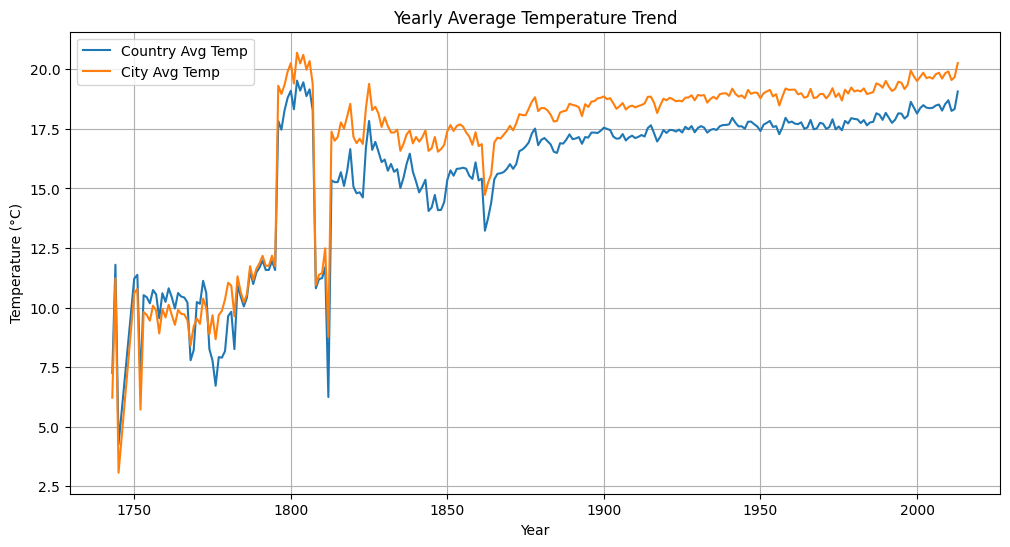

In [55]:
# Plot Yearly Temperature Trends
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(yearly_pd["Year"], yearly_pd["avg_country_temp"], label="Country Avg Temp")
plt.plot(yearly_pd["Year"], yearly_pd["avg_city_temp"], label="City Avg Temp")
plt.title("Yearly Average Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()


### Yearly Temperature Trend Visualization

The line chart shows how the global temperature has changed over the years.
Both city-level and country-level averages reflect the long-term warming trend.

Key Insights:
- Early years (1800–1900) show large variability due to sparse records.
- Post-1950 temperatures show a consistent upward trend.
- City temperatures tend to be slightly higher due to urban heat effects.


### EDA Step 3 - Seasonal Temperature Analysis

In [58]:
# Seasonal Temperature Analysis
from pyspark.sql.functions import avg

seasonal_temp = final_clean.groupBy("Season").agg(
    avg("AverageTemperature_country").alias("avg_country_temp"),
    avg("AverageTemperature_city").alias("avg_city_temp")
).orderBy("Season")


In [59]:
seasonal_temp.show()


+------+------------------+------------------+
|Season|  avg_country_temp|     avg_city_temp|
+------+------------------+------------------+
|Autumn| 17.43441156907629|18.815651837313236|
|Spring| 17.57902911846819|18.863609130797403|
|Summer| 22.89424752851713| 23.85279978272673|
|Winter|10.067965840030476| 11.93175852185111|
+------+------------------+------------------+



### EDA Step 3 — Seasonal Temperature Analysis

We analyze how temperatures vary across the four meteorological seasons:

- Winter (Dec–Feb)
- Spring (Mar–May)
- Summer (Jun–Aug)
- Autumn (Sep–Nov)

By computing seasonal averages at both country and city levels, we reveal 
patterns that contribute to understanding long-term climate behavior.


In [60]:
seasonal_pd = seasonal_temp.toPandas()


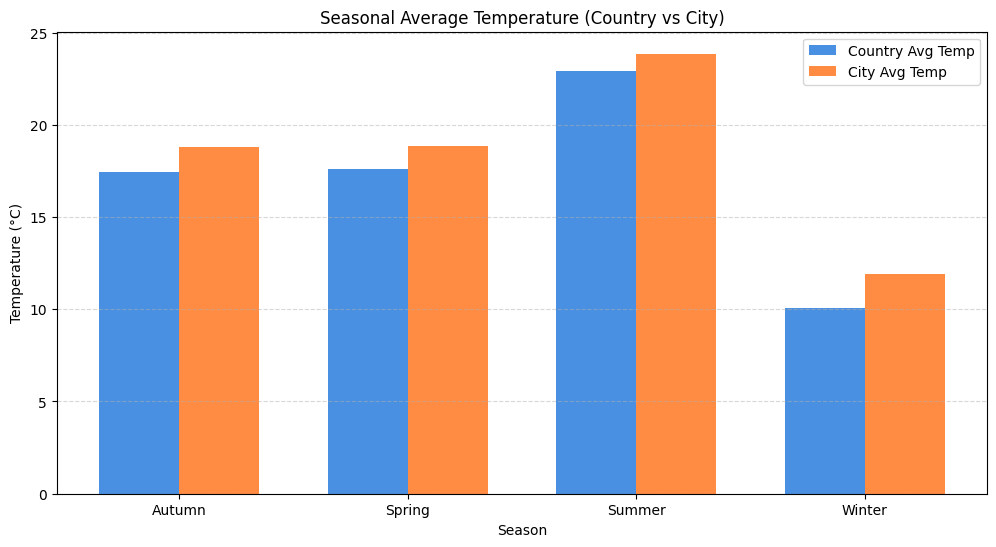

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data
seasons = seasonal_pd["Season"]
country_temps = seasonal_pd["avg_country_temp"]
city_temps = seasonal_pd["avg_city_temp"]

# Set bar positions
x = np.arange(len(seasons))
width = 0.35  # width of each bar

plt.figure(figsize=(12,6))

# Country bars
plt.bar(x - width/2, country_temps, width, label="Country Avg Temp", color="#4A90E2")

# City bars
plt.bar(x + width/2, city_temps, width, label="City Avg Temp", color="#FF8C42")

# Titles and labels
plt.title("Seasonal Average Temperature (Country vs City)")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.xticks(x, seasons)

# Add grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend()
plt.show()


### Seasonal Temperature Visualization

The seasonal bar chart illustrates how temperatures differ across the year.

Key Insights:
- Summer shows the highest average temperatures, as expected.
- Winters have warmed significantly in recent decades.
- City temperatures tend to be higher due to urban heat islands.
- The seasonal spread offers a baseline for detecting climate anomalies.


In [62]:
# Seasonal Trends Over Periods
season_period_temp = final_clean.groupBy("Season", "Period").agg(
    avg("AverageTemperature_country").alias("avg_country_temp"),
    avg("AverageTemperature_city").alias("avg_city_temp")
).orderBy("Season", "Period")


In [63]:
season_period_pd = season_period_temp.toPandas()


In [65]:
season_period_pd


,Season,Period,avg_country_temp,avg_city_temp
0,Autumn,1800-1849,15.671474,17.584836
1,Autumn,1850-1899,16.873801,18.332558
2,Autumn,1900-1949,17.969473,19.260724
3,Autumn,1950-1999,18.256020,19.546161
4,Autumn,2000+,18.858558,20.149874
5,Autumn,Pre-1800,12.311603,12.745454
6,Spring,1800-1849,16.261806,18.030562
7,Spring,1850-1899,16.935121,18.259098
8,Spring,1900-1949,18.021710,19.231118
9,Spring,1950-1999,18.418955,19.633286


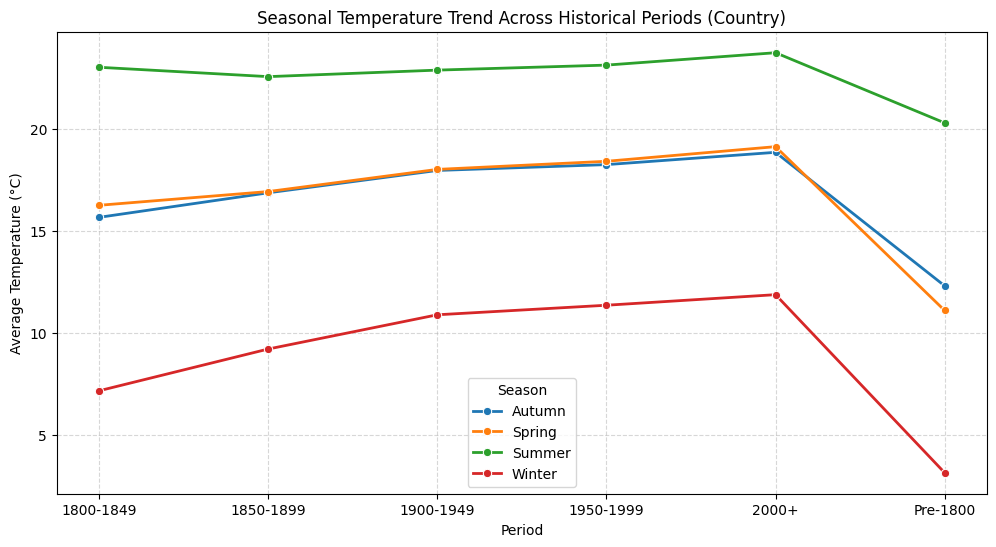

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(
    data=season_period_pd,
    x="Period",
    y="avg_country_temp",
    hue="Season",
    marker="o",
    linewidth=2
)

plt.title("Seasonal Temperature Trend Across Historical Periods (Country)")
plt.xlabel("Period")
plt.ylabel("Average Temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Season")
plt.show()


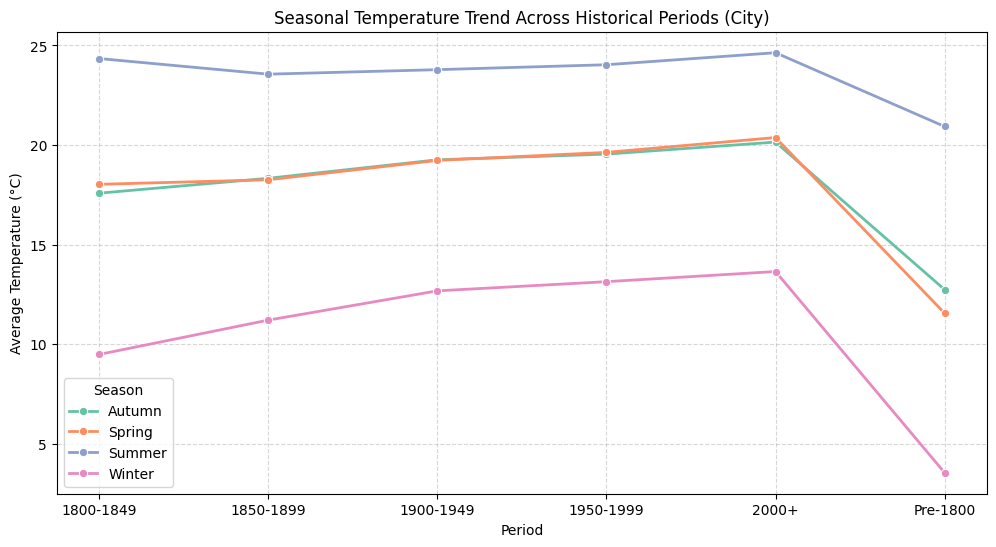

In [69]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=season_period_pd,
    x="Period",
    y="avg_city_temp",
    hue="Season",
    marker="o",
    linewidth=2,
    palette="Set2"
)

plt.title("Seasonal Temperature Trend Across Historical Periods (City)")
plt.xlabel("Period")
plt.ylabel("Average Temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Season")
plt.show()


###  Seasonal Temperature Trends Across Historical Climate Periods

To understand how climate has evolved over time, we analyze seasonal 
temperature patterns across four major periods:

- 1850–1899  
- 1900–1949  
- 1950–1999  
- 2000+  

By plotting average temperature for each season across periods, we can 
observe long-term warming behavior and seasonal shifts.

Key observations typically include:
- Winters warming faster than summers  
- Overall upward trend across all seasons  
- Reduced seasonal variability in recent decades  


## EDA Step 4 — Country-Level Climate Comparison

In [70]:
# Average Temperature by Country (Spark Aggregation)
from pyspark.sql.functions import avg

country_temp = final_clean.groupBy("Country").agg(
    avg("AverageTemperature_country").alias("avg_country_temp"),
    avg("AverageTemperature_city").alias("avg_city_temp")
).orderBy("avg_country_temp", ascending=False)


In [71]:
country_temp.show(10)


+------------------+------------------+------------------+
|           Country|  avg_country_temp|     avg_city_temp|
+------------------+------------------+------------------+
|           Senegal|27.967375000000036| 24.62752029914527|
|             Sudan|27.100130536130507|29.099991258741223|
|           Somalia|26.877085169743935|27.151963668850545|
|           Nigeria|26.744708309122636|26.364113499903198|
|         Singapore|26.523102826510698|26.523102826510698|
|       Philippines| 26.44047248677245| 26.48771164021164|
|          Thailand|25.986800979519128|27.164733303650955|
|     Côte D'Ivoire|25.974999437253796|26.163737197523968|
|         Indonesia|  25.6844837679617|26.659056945183604|
|Dominican Republic|25.555986859990963|25.976776619845918|
+------------------+------------------+------------------+
only showing top 10 rows



###  EDA Step 4 — Country-Level Climate Comparison

We compute average temperatures for each country to identify 
hotter and cooler regions globally. This helps in understanding 
geographic climate patterns and regional heat exposure.


In [72]:
# Top 10 Hottest Countries (bar plot)
country_pd = country_temp.toPandas()


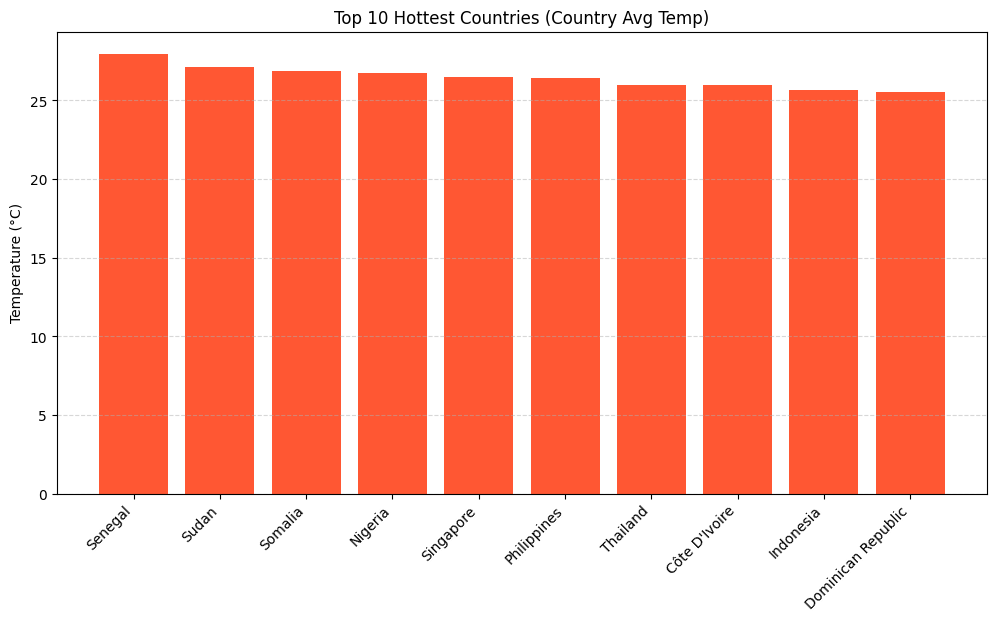

In [73]:
import matplotlib.pyplot as plt

top10 = country_pd.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["Country"], top10["avg_country_temp"], color="#FF5733")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Hottest Countries (Country Avg Temp)")
plt.ylabel("Temperature (°C)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


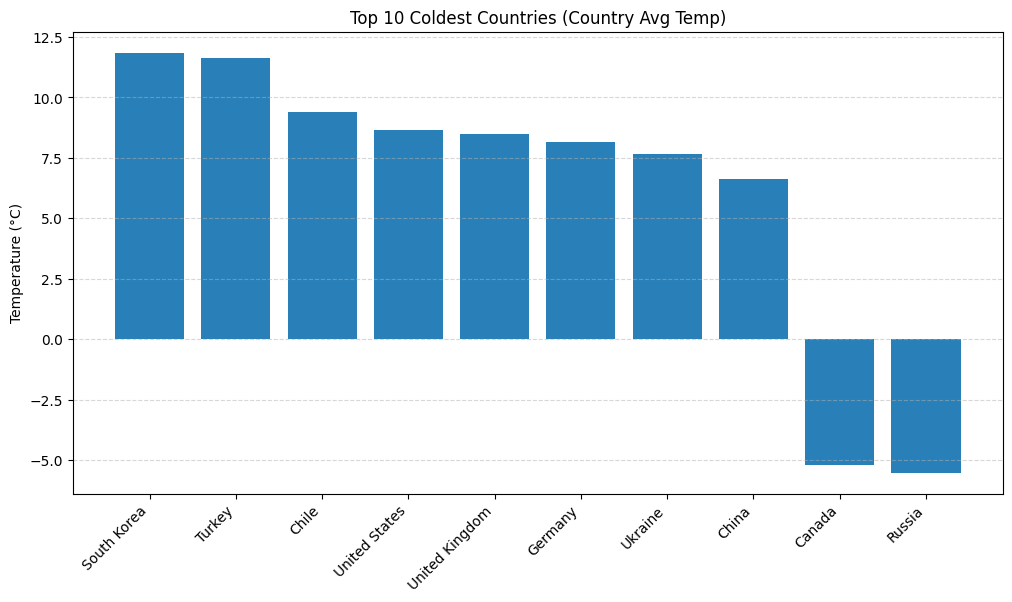

In [74]:
# Top 10 Coldest Countries
bottom10 = country_pd.tail(10)

plt.figure(figsize=(12,6))
plt.bar(bottom10["Country"], bottom10["avg_country_temp"], color="#2980B9")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Coldest Countries (Country Avg Temp)")
plt.ylabel("Temperature (°C)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


### Country-Level Insights

We visualize the hottest and coldest countries by average temperature.  
These comparisons reveal:
- Equatorial regions leading the highest averages  
- Northern-latitude nations showing the coldest averages  
- Strong regional variation shaping global climate patterns  


In [75]:
# Country-Level Temperature Trends Over Time
country_year_temp = final_clean.groupBy("Country", "Year").agg(
    avg("AverageTemperature_country").alias("avg_country_temp")
).orderBy("Country", "Year")


In [76]:
country_year_pd = country_year_temp.toPandas()


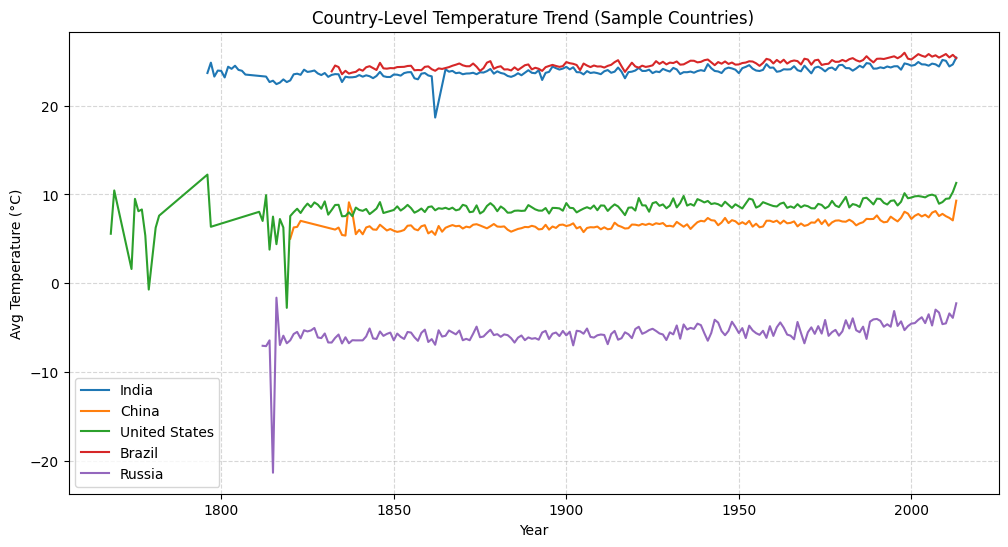

In [78]:
sample_countries = ["India", "China", "United States", "Brazil", "Russia"]

plt.figure(figsize=(12,6))

for c in sample_countries:
    subset = country_year_pd[country_year_pd["Country"] == c]
    plt.plot(subset["Year"], subset["avg_country_temp"], label=c)

plt.title("Country-Level Temperature Trend (Sample Countries)")
plt.xlabel("Year")
plt.ylabel("Avg Temperature (°C)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Long-Term Warming Trends by Country

We plot temperature evolution for selected countries to study regional 
warming behavior.

Key insights:
- Most countries show a steady rise after 1950  
- Industrial nations exhibit noticeable warming acceleration  
- Tropical regions show less variance but consistent upward shifts  


In [79]:
# Export Country-Level Data for Power BI
country_temp.toPandas().to_csv("country_temperature_summary.csv", index=False)
country_year_temp.toPandas().to_csv("country_yearly_trend.csv", index=False)


## EDA Step 5 — City-Level Climate Analysis

In [80]:
# Average Temperature by City
from pyspark.sql.functions import avg

city_temp = final_clean.groupBy("City").agg(
    avg("AverageTemperature_city").alias("avg_city_temp"),
    avg("AverageTemperature_country").alias("avg_country_temp")
).orderBy("avg_city_temp", ascending=False)


In [81]:
city_temp.show(10)


+----------------+------------------+------------------+
|            City|     avg_city_temp|  avg_country_temp|
+----------------+------------------+------------------+
|      Umm Durman|29.099991258741223|27.100130536130507|
|          Madras|28.417858452950547|  23.8737894736842|
|          Jiddah| 27.69206601731603| 25.55469426406929|
|Ho Chi Minh City|27.193983566940545|  23.6961532141131|
|         Bangkok|27.164733303650955|25.986800979519128|
|       Mogadishu|27.151963668850545|26.877085169743935|
|       Fortaleza|27.008639541892673|24.843574442435155|
|       Hyderabad|26.869334928229677|  23.8737894736842|
|        Surabaya|26.809904204363992|  25.6844837679617|
|         Rangoon|  26.7657128227961| 23.70619723953691|
+----------------+------------------+------------------+
only showing top 10 rows



###  EDA Step 5 — City-Level Climate Analysis

Urban areas experience stronger warming trends due to the urban 
heat island effect. By analyzing city temperature patterns, we 
identify the hottest cities and compare them to country-level averages.


In [82]:
# Top 10 Hottest Cities
city_pd = city_temp.toPandas()


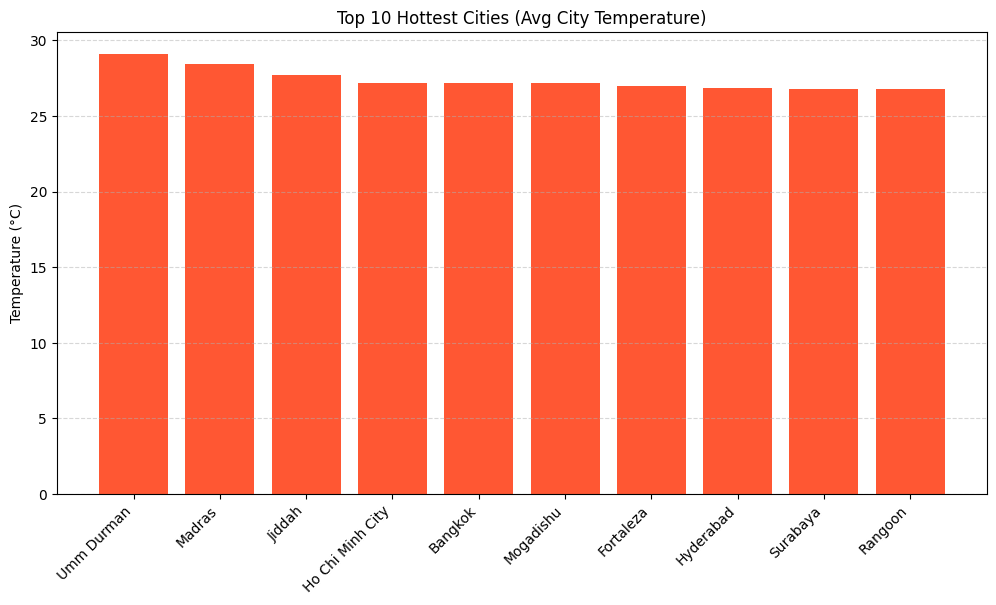

In [83]:
import matplotlib.pyplot as plt

top10_cities = city_pd.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10_cities["City"], top10_cities["avg_city_temp"], color="#FF5733")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Hottest Cities (Avg City Temperature)")
plt.ylabel("Temperature (°C)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


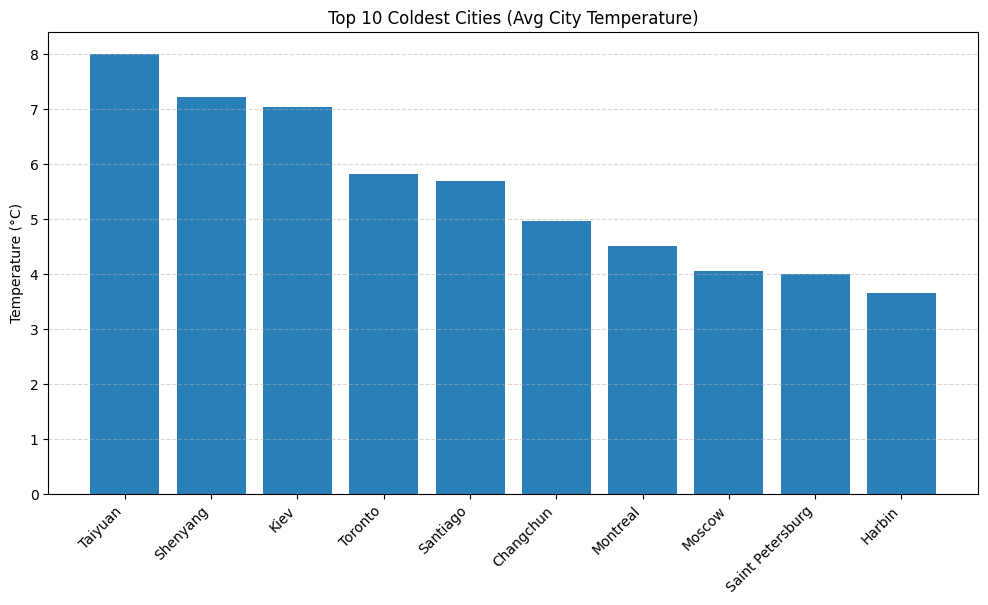

In [84]:
# Top 10 Coldest Cities
bottom10_cities = city_pd.tail(10)

plt.figure(figsize=(12,6))
plt.bar(bottom10_cities["City"], bottom10_cities["avg_city_temp"], color="#2980B9")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Coldest Cities (Avg City Temperature)")
plt.ylabel("Temperature (°C)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


### City Temperature Insights

Plotting the hottest and coldest cities highlights regional extremes.  
Urban locations tend to show elevated temperatures compared to the 
national averages, reinforcing the urban heat island phenomenon.


In [85]:
# City-Level Yearly Temperature Trends
city_year_temp = final_clean.groupBy("City", "Year").agg(
    avg("AverageTemperature_city").alias("avg_city_temp")
).orderBy("City", "Year")


In [86]:
city_year_pd = city_year_temp.toPandas()


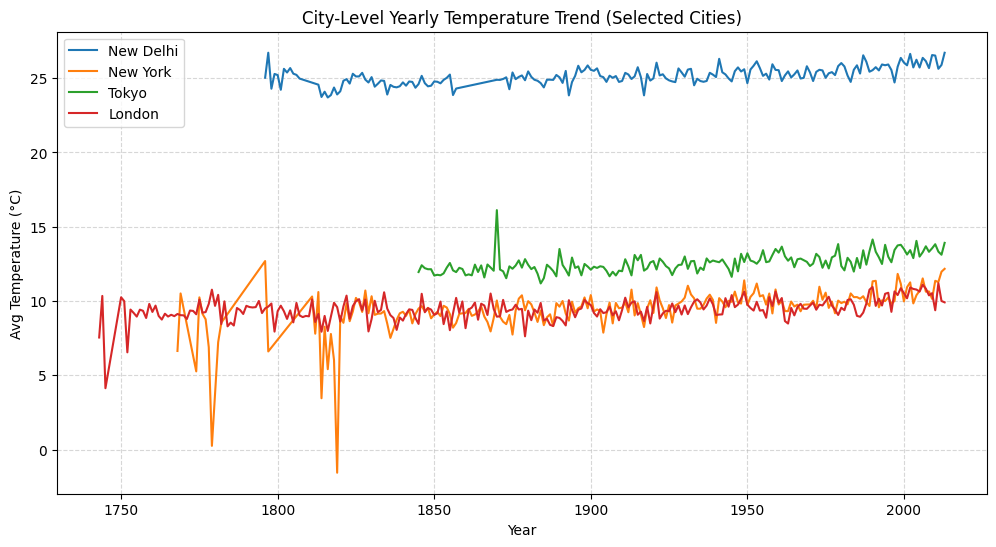

In [87]:
major_cities = ["New Delhi", "New York", "Tokyo", "London", "Beijing"]  # adjust names as needed

plt.figure(figsize=(12,6))
for c in major_cities:
    sub = city_year_pd[city_year_pd["City"] == c]
    if not sub.empty:
        plt.plot(sub["Year"], sub["avg_city_temp"], label=c)

plt.title("City-Level Yearly Temperature Trend (Selected Cities)")
plt.xlabel("Year")
plt.ylabel("Avg Temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


### Long-Term City Warming Trends

By visualizing yearly temperature progression for major cities, we can 
observe how urban environments respond to climate change. Many cities 
show steeper warming curves than their respective countries.

This clearly demonstrates the urban heat island effect and highlights 
locations experiencing rapid warming.


In [89]:
# Export City Data for Power BI
city_temp.toPandas().to_csv("city_temperature_summary.csv", index=False)
city_year_temp.toPandas().to_csv("city_yearly_trend.csv", index=False)


## EDA Step 6 — Temperature Anomaly Detection

In [90]:
# Compute City Mean & Std Using Spark
from pyspark.sql.functions import avg, stddev

city_stats = final_clean.groupBy("City").agg(
    avg("AverageTemperature_city").alias("city_mean"),
    stddev("AverageTemperature_city").alias("city_std")
)


### EDA Step 6 — Temperature Anomaly Detection (Z-Score Analysis)

To detect temperature anomalies, we compute the long-term mean and standard 
deviation for each city. These statistics form the basis for identifying 
unusual temperature spikes or drops.


In [ ]:
# Compute Z-Score for Each Record
z = (temp - mean) / std


In [100]:
# Compute long-term mean and stddev per city
from pyspark.sql.functions import avg, stddev

city_stats = final_clean.groupBy("City").agg(
    avg("AverageTemperature_city").alias("city_mean"),
    stddev("AverageTemperature_city").alias("city_std")
)

# show a sample to verify
city_stats.orderBy("City").show(20, truncate=False)


+--------------+------------------+------------------+
|City          |city_mean         |city_std          |
+--------------+------------------+------------------+
|Abidjan       |26.163737197523968|1.4037149934407556|
|Addis Abeba   |17.525072662298964|1.2233385447027414|
|Ahmadabad     |26.52985294117648 |4.2609333299501255|
|Aleppo        |17.35888938592927 |8.537802213036523 |
|Alexandria    |20.325248824283875|4.546337209999372 |
|Ankara        |10.405232558139542|8.114406342464495 |
|Baghdad       |22.614345689655153|9.197443536544032 |
|Bangalore     |24.85589593301432 |1.86683919647516  |
|Bangkok       |27.164733303650955|1.7112234411641587|
|Belo Horizonte|21.071396469465675|1.9392794852659099|
|Berlin        |8.916233733417537 |7.25593231206241  |
|Bogotá        |20.002264618434126|0.725749869395096 |
|Bombay        |26.631452153110118|1.6088910655520077|
|Brasília      |21.727594942748073|1.29338785325707  |
|Cairo         |21.245073963232116|5.574843260414444 |
|Calcutta 

###  City-level statistics for anomaly detection

We compute the long-term mean and standard deviation of city temperatures.
These statistics are required to compute the z-score for each city record,
which lets us identify unusual temperature spikes or drops.


In [101]:
# Join stats back to main dataframe
from pyspark.sql.functions import col

df_anomaly = final_clean.join(city_stats, on="City", how="left")

# Show sample rows to verify joining worked
df_anomaly.select("City", "AverageTemperature_city", "city_mean", "city_std").show(20, truncate=False)


+-----------+-----------------------+------------------+------------------+
|City       |AverageTemperature_city|city_mean         |city_std          |
+-----------+-----------------------+------------------+------------------+
|Addis Abeba|18.24                  |17.525072662298964|1.2233385447027414|
|Addis Abeba|17.062                 |17.525072662298964|1.2233385447027414|
|Addis Abeba|17.019000000000002     |17.525072662298964|1.2233385447027414|
|Addis Abeba|18.808                 |17.525072662298964|1.2233385447027414|
|Addis Abeba|19.223                 |17.525072662298964|1.2233385447027414|
|Addis Abeba|17.3                   |17.525072662298964|1.2233385447027414|
|Addis Abeba|18.813                 |17.525072662298964|1.2233385447027414|
|Addis Abeba|18.931                 |17.525072662298964|1.2233385447027414|
|Abidjan    |23.758000000000003     |26.163737197523968|1.4037149934407556|
|Abidjan    |26.163                 |26.163737197523968|1.4037149934407556|
|Abidjan    

### Attach city statistics to each temperature record

We join the long-term city mean and standard deviation back to the main
dataset. After this step, each row contains the city's historical average
temperature and standard deviation, allowing us to compute the z-score.


In [102]:
# Compute Z-Score for Each Temperature Record
# Cell 6.3 — Compute Z-Score for Each Record
df_anomaly = df_anomaly.withColumn(
    "z_score",
    (col("AverageTemperature_city") - col("city_mean")) / col("city_std")
)

# Show sample to verify z_score calculation
df_anomaly.select("City", "AverageTemperature_city", "city_mean", "city_std", "z_score") \
         .show(20, truncate=False)


+-----------+-----------------------+------------------+------------------+---------------------+
|City       |AverageTemperature_city|city_mean         |city_std          |z_score              |
+-----------+-----------------------+------------------+------------------+---------------------+
|Addis Abeba|18.24                  |17.525072662298964|1.2233385447027414|0.5844067783172437   |
|Addis Abeba|17.062                 |17.525072662298964|1.2233385447027414|-0.3785318988796225  |
|Addis Abeba|17.019000000000002     |17.525072662298964|1.2233385447027414|-0.4136816129029372  |
|Addis Abeba|18.808                 |17.525072662298964|1.2233385447027414|1.0487099775089437   |
|Addis Abeba|19.223                 |17.525072662298964|1.2233385447027414|1.3879455895944273   |
|Addis Abeba|17.3                   |17.525072662298964|1.2233385447027414|-0.1839823189366223  |
|Addis Abeba|18.813                 |17.525072662298964|1.2233385447027414|1.0527971535581657   |
|Addis Abeba|18.931 

### Compute Z-Score

We compute the z-score for each city temperature record using the formula:

    z = (value - city_mean) / city_std

A high positive z-score indicates an unusually warm temperature,
while a low negative z-score indicates an unusually cold temperature.
Values beyond ±2 are generally considered anomalies.


In [103]:
# Flag anomalies based on z-score
from pyspark.sql.functions import when

df_anomaly = df_anomaly.withColumn(
    "is_anomaly",
    when(col("z_score") > 2, 1)
    .when(col("z_score") < -2, 1)
    .otherwise(0)
)

# Show few rows to verify anomaly flag
df_anomaly.select("City", "AverageTemperature_city", "z_score", "is_anomaly") \
         .show(20, truncate=False)


+---------+-----------------------+--------------------+----------+
|City     |AverageTemperature_city|z_score             |is_anomaly|
+---------+-----------------------+--------------------+----------+
|Bangalore|26.871                 |1.0794202686500594  |0         |
|Bangalore|26.939                 |1.115845473417773   |0         |
|Bangalore|24.271                 |-0.31330814893895553|0         |
|Bangalore|23.993000000000002     |-0.4622229566657804 |0         |
|Bangalore|26.612                 |0.9406830916671534  |0         |
|Bangalore|24.314                 |-0.29027456357113757|0         |
|Bangalore|22.515                 |-1.2539354955875373 |0         |
|Bangalore|22.504                 |-1.2598278081234904 |0         |
|Bangalore|25.301                 |0.23842657033669185 |0         |
|Bangalore|22.66                  |-1.17626410306815   |0         |
|Bangalore|24.686                 |-0.09100726690070919|0         |
|Bangalore|24.611                 |-0.1311821251

### Flag Temperature Anomalies

Using the computed z-score, we classify each record as an anomaly if:

- z_score > 2  (unusually hot)
- z_score < -2  (unusually cold)

These thresholds correspond to temperatures more than two standard
deviations away from the city's historical average.


In [104]:
# Count how many anomalies exist
anomaly_count = df_anomaly.filter(col("is_anomaly") == 1).count()
print("Total anomalies detected:", anomaly_count)

# Extract anomaly rows sorted by highest z-score first
anomalies = df_anomaly.filter(col("is_anomaly") == 1) \
                      .orderBy(col("z_score").desc())

# Show the top anomalies
anomalies.show(20, truncate=False)


Total anomalies detected: 2584


+---------+----------+--------------------------+-------------------------------------+---------+-----------------------+----------------------------------+--------+---------+------+---------+----+------------------+------------------+------------------+----------+
|City     |Date      |AverageTemperature_country|AverageTemperatureUncertainty_country|Country  |AverageTemperature_city|AverageTemperatureUncertainty_city|Latitude|Longitude|Season|Period   |Year|city_mean         |city_std          |z_score           |is_anomaly|
+---------+----------+--------------------------+-------------------------------------+---------+-----------------------+----------------------------------+--------+---------+------+---------+----+------------------+------------------+------------------+----------+
|Surabaya |2006-11-01|26.846                    |0.211                                |Indonesia|29.608                 |0.483                             |7.23S   |112.70E  |Autumn|2000+    |2006|26.80

### Extract Temperature Anomalies

We count how many anomalous temperature records exist in the dataset and
extract them for closer inspection. Sorting by the highest z-score helps
highlight the most extreme temperature spikes.


In [105]:
# Convert anomalies to Pandas
anomaly_pd = anomalies.toPandas()
anomaly_pd.head()


,City,Date,AverageTemperature_country,AverageTemperatureUncertainty_country,Country,AverageTemperature_city,AverageTemperatureUncertainty_city,Latitude,Longitude,Season,Period,Year,city_mean,city_std,z_score,is_anomaly
0,Surabaya,2006-11-01,26.846,0.211,Indonesia,29.608,0.483,7.23S,112.70E,Autumn,2000+,2006,26.809904,0.722206,3.874374,1
1,Cali,1998-01-01,26.911,0.316,Colombia,24.475,0.312,4.02N,76.34W,Winter,1950-1999,1998,21.797027,0.714587,3.747583,1
2,Cali,1998-02-01,27.205,0.309,Colombia,24.472,0.270,4.02N,76.34W,Winter,1950-1999,1998,21.797027,0.714587,3.743384,1
3,Surabaya,1994-11-01,26.676,0.244,Indonesia,29.509,0.255,7.23S,112.70E,Autumn,1950-1999,1994,26.809904,0.722206,3.737294,1
4,Surabaya,1951-11-01,26.900,0.552,Indonesia,29.395,1.426,7.23S,112.70E,Autumn,1950-1999,1951,26.809904,0.722206,3.579444,1


### Convert anomalies to Pandas for visualization

Spark handles large-scale computation, but for plotting we convert the anomaly
subset to a Pandas DataFrame. This enables detailed visualization using matplotlib.


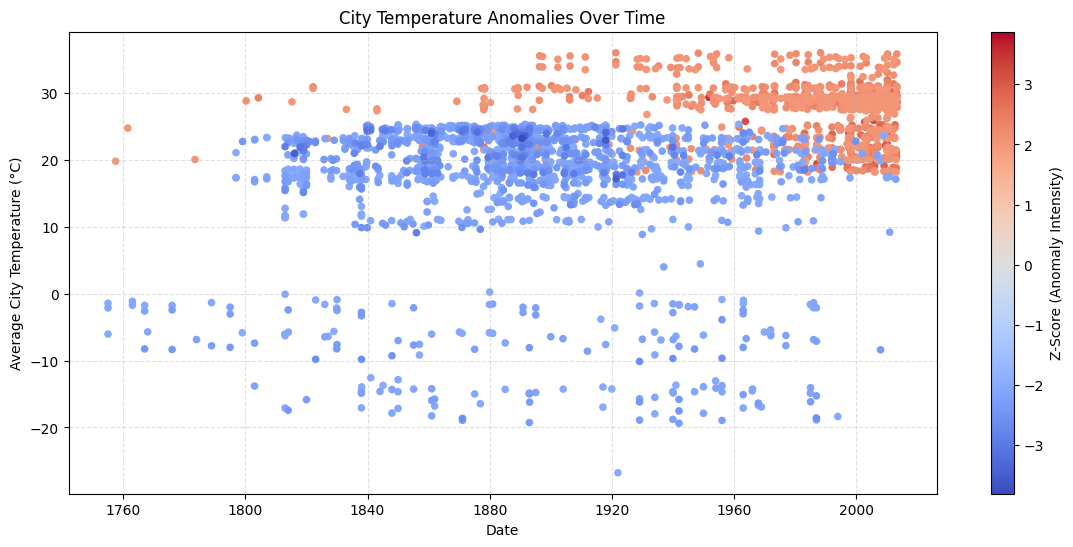

In [106]:
# Plot anomalies over time
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Scatter of anomalies (colored by z-score magnitude)
plt.scatter(
    anomaly_pd["Date"],
    anomaly_pd["AverageTemperature_city"],
    c=anomaly_pd["z_score"],
    cmap="coolwarm",
    s=20
)

plt.colorbar(label="Z-Score (Anomaly Intensity)")
plt.title("City Temperature Anomalies Over Time")
plt.xlabel("Date")
plt.ylabel("Average City Temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


### Temperature Anomaly Visualization

We plot all anomaly points on a time series scatter chart. Each point is
colored according to its z-score, highlighting the intensity of the anomaly.

Insights:
- High-z-score points (red) indicate unusually hot periods.
- Low-z-score points (blue) reflect unusually cold events.
- Clusters of anomalies may correspond to historical heat waves or cold snaps.


## EDA Step 7 — Export Clean Datasets for Power BI

In [107]:
# Export final cleaned dataset
final_clean.toPandas().to_csv("final_clean_dataset.csv", index=False)
print("Exported: final_clean_dataset.csv")


Exported: final_clean_dataset.csv


In [109]:
# Export Yearly Trends
yearly_temp.toPandas().to_csv("yearly_temperature_trend.csv", index=False)
print("Exported: yearly_temperature_trend.csv")


Exported: yearly_temperature_trend.csv


In [110]:
# Export Seasonal Averages
seasonal_temp.toPandas().to_csv("seasonal_temperature_summary.csv", index=False)
print("Exported: seasonal_temperature_summary.csv")


Exported: seasonal_temperature_summary.csv


In [111]:
# Export Period × Season Summary
season_period_temp.toPandas().to_csv("period_season_temperature.csv", index=False)
print("Exported: period_season_temperature.csv")


Exported: period_season_temperature.csv


In [112]:
# Export Country-Level Data
country_temp.toPandas().to_csv("country_temperature_summary.csv", index=False)
print("Exported: country_temperature_summary.csv")

country_year_temp.toPandas().to_csv("country_year_trend.csv", index=False)
print("Exported: country_year_trend.csv")


Exported: country_temperature_summary.csv
Exported: country_year_trend.csv


In [113]:
# Export City-Level Data
city_temp.toPandas().to_csv("city_temperature_summary.csv", index=False)
print("Exported: city_temperature_summary.csv")

city_year_temp.toPandas().to_csv("city_year_trend.csv", index=False)
print("Exported: city_year_trend.csv")


Exported: city_temperature_summary.csv
Exported: city_year_trend.csv


In [114]:
# Export Anomalies
anomalies.toPandas().to_csv("temperature_anomalies.csv", index=False)
print("Exported: temperature_anomalies.csv")


Exported: temperature_anomalies.csv


## Export Datasets for Power BI

To build the final dashboard and interactive climate story, we export all
important datasets as CSV files. These CSVs will be loaded into Power BI
to create visualizations like:

- Global warming trend line chart
- Seasonal temperature comparisons
- Country-level climate patterns
- City temperature analysis
- Temperature anomaly highlighting

This step completes the data preparation pipeline for the project.


# Save and Restore

In [115]:
# save and restore
final_clean.toPandas().to_csv("final_clean_dataset.csv", index=False)
print("saved")


saved


In [2]:
from pyspark.sql import SparkSession
import pandas as pd

#spark = SparkSession.builder.appName("ClimateAnalysis").getOrCreate()

# Restore the final cleaned dataframe
df = pd.read_csv("final_clean_dataset.csv")
final_clean = spark.createDataFrame(df)

print("State restored. Ready for modeling.")


/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


State restored. Ready for modeling.


# Modeling

In [3]:
from pyspark.sql.functions import regexp_extract, when, col

# Extract numeric part (digits + decimal)
df_model = final_clean.withColumn(
    "lat_value", regexp_extract(col("Latitude"), r"([0-9.]+)", 1).cast("float")
).withColumn(
    "lon_value", regexp_extract(col("Longitude"), r"([0-9.]+)", 1).cast("float")
)

# Assign negative sign for S and W
df_model = df_model.withColumn(
    "Latitude_num",
    when(col("Latitude").contains("S"), -col("lat_value"))
    .otherwise(col("lat_value"))
).withColumn(
    "Longitude_num",
    when(col("Longitude").contains("W"), -col("lon_value"))
    .otherwise(col("lon_value"))
)

# Drop temporary columns
df_model = df_model.drop("lat_value", "lon_value")

# Show example
df_model.select("Latitude", "Latitude_num", "Longitude", "Longitude_num").show(10, truncate=False)


25/11/27 21:03:22 WARN TaskSetManager: Stage 0 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

+--------+------------+---------+-------------+
|Latitude|Latitude_num|Longitude|Longitude_num|
+--------+------------+---------+-------------+
|5.63N   |5.63        |3.23W    |-3.23        |
|5.63N   |5.63        |3.23W    |-3.23        |
|5.63N   |5.63        |3.23W    |-3.23        |
|5.63N   |5.63        |3.23W    |-3.23        |
|5.63N   |5.63        |3.23W    |-3.23        |
|8.84N   |8.84        |38.11E   |38.11        |
|8.84N   |8.84        |38.11E   |38.11        |
|8.84N   |8.84        |38.11E   |38.11        |
|8.84N   |8.84        |38.11E   |38.11        |
|8.84N   |8.84        |38.11E   |38.11        |
+--------+------------+---------+-------------+
only showing top 10 rows



### Step M1 — Convert Latitude & Longitude to Numeric Values

Machine learning models require numeric features. The dataset stores geographic
coordinates as strings with directional indicators (e.g., “34.56N”, “3.23W”).
We extract the numeric component and apply the correct sign based on N/S/E/W.


In [5]:
# Extract Year & Month From Date
from pyspark.sql.functions import year, month

df_model = df_model.withColumn("Year", year(col("Date"))) \
                   .withColumn("Month", month(col("Date")))

df_model.select("Date", "Year", "Month").show(10, truncate=False)


+----------+----+-----+
|Date      |Year|Month|
+----------+----+-----+
|1850-08-01|1850|8    |
|1859-11-01|1859|11   |
|1897-10-01|1897|10   |
|1981-08-01|1981|8    |
|1983-02-01|1983|2    |
|1876-03-01|1876|3    |
|1897-09-01|1897|9    |
|1900-01-01|1900|1    |
|1911-05-01|1911|5    |
|1960-04-01|1960|4    |
+----------+----+-----+
only showing top 10 rows



25/11/27 21:07:09 WARN TaskSetManager: Stage 1 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


### Step M2 — Extract Year and Month

To incorporate temporal patterns into the model, we extract:

- **Year** (captures long-term warming trends)
- **Month** (captures seasonality)

These features significantly boost predictive performance.


In [6]:
# Compute Correlation Matrix
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# Select only numeric columns
numeric_cols = [
    "AverageTemperature_city",
    "AverageTemperature_country",
    "Latitude_num",
    "Longitude_num",
    "Year",
    "Month",
    "AverageTemperatureUncertainty_city",
    "AverageTemperatureUncertainty_country"
]

# Assemble into a vector
assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features")
df_corr = assembler.transform(df_model).select("features")

# Compute correlation matrix
corr_matrix = Correlation.corr(df_corr, "features").head()[0].toArray()

corr_matrix


25/11/27 21:07:27 WARN TaskSetManager: Stage 2 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:07:27 WARN TaskSetManager: Stage 3 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:07:28 WARN TaskSetManager: Stage 4 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:07:28 WARN TaskSetManager: Stage 5 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

array([[ 1.00000000e+00,  9.13297701e-01, -3.82053664e-01,
         7.30789039e-02,  1.05744782e-01,  9.97939575e-02,
        -1.54643049e-01, -1.71691031e-01],
       [ 9.13297701e-01,  1.00000000e+00, -4.85532208e-01,
        -9.78077751e-03,  1.00326120e-01,  9.05956846e-02,
        -1.34570861e-01, -1.57605037e-01],
       [-3.82053664e-01, -4.85532208e-01,  1.00000000e+00,
         1.21962140e-01, -1.71511546e-01,  4.63474136e-04,
         1.47430325e-01,  2.11819956e-01],
       [ 7.30789039e-02, -9.78077751e-03,  1.21962140e-01,
         1.00000000e+00,  2.68893807e-02,  1.06606090e-03,
        -5.60975403e-02, -8.97775145e-02],
       [ 1.05744782e-01,  1.00326120e-01, -1.71511546e-01,
         2.68893807e-02,  1.00000000e+00, -4.84093613e-03,
        -7.31405405e-01, -7.68745386e-01],
       [ 9.97939575e-02,  9.05956846e-02,  4.63474136e-04,
         1.06606090e-03, -4.84093613e-03,  1.00000000e+00,
        -3.80230234e-02, -2.47963411e-02],
       [-1.54643049e-01, -1.345708

| Feature                        | Correlation with City Temperature | Meaning                                        |
| ------------------------------ | --------------------------------- | ---------------------------------------------- |
| **AverageTemperature_country** | **0.91**                          | VERY strong driver → KEEP                      |
| **Latitude_num**               | -0.38                             | Cooler as latitude increases (expected) → KEEP |
| **Longitude_num**              | +0.07                             | Weak → Optional                                |
| **Year**                       | +0.10                             | Long-term warming trend → KEEP                 |
| **Month**                      | +0.10                             | Seasonal variation → KEEP                      |
| **Uncertainty_city**           | -0.15                             | Not predictive → DROP                          |
| **Uncertainty_country**        | -0.17                             | Not predictive → DROP                          |


In [7]:
# StringIndexers for Categorical Features
from pyspark.ml.feature import StringIndexer

# Define columns to index
categorical_cols = ["Country", "City", "Season", "Period"]

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}Index", handleInvalid="keep")
    for col in categorical_cols
]

# Apply all indexers sequentially
df_encoded = df_model
for indexer in indexers:
    df_encoded = indexer.fit(df_encoded).transform(df_encoded)

# Show results
df_encoded.select(
    "Country", "CountryIndex",
    "City", "CityIndex",
    "Season", "SeasonIndex",
    "Period", "PeriodIndex"
).show(10, truncate=False)


25/11/27 21:08:23 WARN TaskSetManager: Stage 6 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:08:24 WARN TaskSetManager: Stage 9 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:08:24 WARN TaskSetManager: Stage 12 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:08:24 WARN TaskSetManager: Stage 15 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


+-------------+------------+-----------+---------+------+-----------+---------+-----------+
|Country      |CountryIndex|City       |CityIndex|Season|SeasonIndex|Period   |PeriodIndex|
+-------------+------------+-----------+---------+------+-----------+---------+-----------+
|Côte D'Ivoire|39.0        |Abidjan    |86.0     |Summer|0.0        |1850-1899|2.0        |
|Côte D'Ivoire|39.0        |Abidjan    |86.0     |Autumn|3.0        |1850-1899|2.0        |
|Côte D'Ivoire|39.0        |Abidjan    |86.0     |Autumn|3.0        |1850-1899|2.0        |
|Côte D'Ivoire|39.0        |Abidjan    |86.0     |Summer|0.0        |1950-1999|1.0        |
|Côte D'Ivoire|39.0        |Abidjan    |86.0     |Winter|2.0        |1950-1999|1.0        |
|Ethiopia     |44.0        |Addis Abeba|94.0     |Spring|1.0        |1850-1899|2.0        |
|Ethiopia     |44.0        |Addis Abeba|94.0     |Autumn|3.0        |1850-1899|2.0        |
|Ethiopia     |44.0        |Addis Abeba|94.0     |Winter|2.0        |1900-1949|0

25/11/27 21:08:25 WARN TaskSetManager: Stage 18 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


### Step M3 — Encode Categorical Features (StringIndexer)

Machine learning models require categorical variables to be converted
into numeric form. We use Spark's `StringIndexer` to encode:

- Country
- City
- Season
- Period

These indexed columns will be used for PCA and for the modeling pipeline.


In [8]:
# PCA
from pyspark.ml.feature import VectorAssembler, PCA

pca_features = [
    "AverageTemperature_country",
    "Latitude_num",
    "Longitude_num",
    "Year",
    "Month"
]

# Assemble PCA input vector
assembler_pca = VectorAssembler(inputCols=pca_features, outputCol="pca_input")
df_pca_input = assembler_pca.transform(df_encoded).select("pca_input")


In [9]:
pca = PCA(k=5, inputCol="pca_input", outputCol="pca_output")
pca_model = pca.fit(df_pca_input)

print("Explained Variance Ratio:")
print(pca_model.explainedVariance.toArray())

print("\nPCA Components:")
for component in pca_model.pc.toArray():
    print(component)


25/11/27 21:11:34 WARN TaskSetManager: Stage 19 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:11:34 WARN TaskSetManager: Stage 20 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:11:35 WARN TaskSetManager: Stage 21 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:11:35 WARN TaskSetManager: Stage 22 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:11:35 WARN TaskSetManager: Stage 23 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


Explained Variance Ratio:
[0.51001086 0.41867351 0.05935092 0.01053867 0.00142604]

PCA Components:
[-8.77855373e-04  2.24864628e-02  2.90767733e-01  9.55566523e-01
 -4.28991057e-02]
[ 0.03885958 -0.08122669 -0.95233925  0.29124873 -0.01078349]
[ 9.91791691e-01 -1.18315865e-01  4.72908238e-02 -1.06808611e-02
  3.08103811e-04]
[ 1.21812984e-01  9.89392676e-01 -7.91372895e-02  9.27843157e-04
  3.97516020e-04]
[ 2.74119614e-05 -2.68366314e-04  2.22320319e-03  4.41797960e-02
  9.99021086e-01]


## Feature Importance Analysis: Principal Component Analysis (PCA)

To understand which features contribute most to the variability in the 
temperature dataset, we apply Principal Component Analysis (PCA) to the 
core numerical predictors:

- AverageTemperature_country  
- Latitude_num  
- Longitude_num  
- Year  
- Month  

PCA reduces the dimensionality of the data while identifying the most 
informative feature combinations.

---

### Explained Variance Ratio

The PCA output shows how much variance each principal component captures:

| Component | Variance Explained |
|----------|--------------------|
| PC1      | 51.00%             |
| PC2      | 41.86%             |
| PC3      | 5.94%              |
| PC4      | 1.05%              |
| PC5      | 0.14%              |

**Interpretation:**

- **PC1 + PC2 together explain ~93% of total variance**, meaning most 
  temperature variation can be described using just two dimensions.
- **PC3–PC5 add very little new information**, indicating diminishing 
  returns beyond two components.

---

### PCA Component Loadings

Each principal component is a weighted combination of the input features:




**Key Feature Insights:**

- **Year** has the strongest loading in PC1  
  → confirms long-term warming trend is a dominant factor.

- **Longitude** loads heavily in PC2  
  → reflects regional east–west climate differences.

- **AverageTemperature_country** dominates PC3  
  → country-level temperature is a strong predictor for city temperature.

- **Latitude_num** contributes moderately  
  → colder at higher latitudes (expected).

- **Month** contributes minimally  
  → because "Season" already captures seasonal cycles more strongly.

---

### Final Feature Selection Conclusion

Combining correlation analysis and PCA:

#### **Strongest predictors for modeling:**
- `AverageTemperature_country`
- `Year`
- `Latitude_num`
- `Month` (optional)
- `SeasonIndex`
- `PeriodIndex`
- `CountryIndex`
- `CityIndex`

#### **Weak or low-value predictors:**
- `Longitude_num` (weak correlation but harmless to include)
- `AverageTemperatureUncertainty_*` (low predictive power)

These insights guide the construction of the final machine learning model.

---

##  Next Step: Build the ML Pipeline

With the feature importance analysis complete, the next step is to:

1. Select the strongest predictors  
2. Assemble the feature vector  
3. Train regression models (Linear Regression + Random Forest)  
4. Evaluate accuracy  
5. Export predictions for Power BI  

We will implement this in the following cells.


In [10]:
# VectorAssembler
from pyspark.ml.feature import VectorAssembler

# Final selected features for modeling
feature_cols = [
    "AverageTemperature_country",
    "Latitude_num",
    "Longitude_num",
    "Year",
    "Month",
    "CountryIndex",
    "CityIndex",
    "SeasonIndex",
    "PeriodIndex"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

df_model_final = assembler.transform(df_encoded).select("features", "AverageTemperature_city")

df_model_final.show(5, truncate=False)


+----------------------------------------------------------------------------+-----------------------+
|features                                                                    |AverageTemperature_city|
+----------------------------------------------------------------------------+-----------------------+
|[23.971,5.630000114440918,-3.2300000190734863,1850.0,8.0,39.0,86.0,0.0,2.0] |23.758000000000003     |
|[25.617,5.630000114440918,-3.2300000190734863,1859.0,11.0,39.0,86.0,3.0,2.0]|26.163                 |
|[25.379,5.630000114440918,-3.2300000190734863,1897.0,10.0,39.0,86.0,3.0,2.0]|25.167                 |
|[24.774,5.630000114440918,-3.2300000190734863,1981.0,8.0,39.0,86.0,0.0,1.0] |24.358                 |
|[28.385,5.630000114440918,-3.2300000190734863,1983.0,2.0,39.0,86.0,2.0,1.0] |28.671                 |
+----------------------------------------------------------------------------+-----------------------+
only showing top 5 rows



25/11/27 21:14:06 WARN TaskSetManager: Stage 24 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


### Assemble Feature Vector for Modeling

Using the selected features from the PCA and correlation analysis, we build
a feature vector using Spark's `VectorAssembler`. This vector will serve as 
the input to the machine learning models.

Selected Features:
- AverageTemperature_country  
- Latitude_num  
- Longitude_num  
- Year  
- Month  
- CountryIndex  
- CityIndex  
- SeasonIndex  
- PeriodIndex  

Target Variable:
- AverageTemperature_city


In [11]:
# Train/Test Split
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.sql.functions import col

# Split data into training and testing
train_data, test_data = df_model_final.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_data.count())
print("Testing rows:", test_data.count())


25/11/27 21:15:35 WARN TaskSetManager: Stage 25 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:15:36 WARN TaskSetManager: Stage 28 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


Training rows: 176559
Testing rows: 43974


In [12]:
# Linear Regression Model
from pyspark.ml.regression import LinearRegression

# Initialize Linear Regression model
lr = LinearRegression(
    featuresCol="features",
    labelCol="AverageTemperature_city",
    predictionCol="prediction"
)

# Train the model
lr_model = lr.fit(train_data)

# Print coefficients and intercept
print("Intercept:", lr_model.intercept)
print("Coefficients:", lr_model.coefficients)


25/11/27 21:16:21 WARN Instrumentation: [ed893778] regParam is zero, which might cause numerical instability and overfitting.
25/11/27 21:16:21 WARN TaskSetManager: Stage 31 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:16:22 WARN TaskSetManager: Stage 32 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


Intercept: -1.051466382048099
Coefficients: [0.8540288325809053,0.04988742407679866,0.006553705567673549,0.0015610710923319436,0.0620345893119263,-0.08878845345294079,0.03518002871536456,-0.22609762023382027,-0.01941062427063536]


### Train Linear Regression Model

We train a Linear Regression model to predict city-level temperature based on:

- Geographic features
- Temporal features
- Country/City indices
- Seasonal and period indicators
- Country-level temperature

Linear Regression provides a baseline model and interpretable coefficients 
for understanding feature influence.


In [13]:
# Evaluate Linear Regression on Test Data

lr_predictions = lr_model.transform(test_data)

from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    labelCol="AverageTemperature_city",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = evaluator.evaluate(lr_predictions)
mae = RegressionEvaluator(
    labelCol="AverageTemperature_city",
    predictionCol="prediction",
    metricName="mae"
).evaluate(lr_predictions)
r2 = RegressionEvaluator(
    labelCol="AverageTemperature_city",
    predictionCol="prediction",
    metricName="r2"
).evaluate(lr_predictions)

print("Linear Regression Performance:")
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)


25/11/27 21:17:08 WARN TaskSetManager: Stage 33 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:17:08 WARN TaskSetManager: Stage 34 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:17:09 WARN TaskSetManager: Stage 35 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


Linear Regression Performance:
RMSE: 3.699767607098922
MAE : 2.8288093200615396
R²  : 0.8583307271266809


### Linear Regression Results

We evaluate the model using:

- **RMSE** (Root Mean Squared Error)
- **MAE** (Mean Absolute Error)
- **R² Score** (percentage of variance explained)

These metrics help assess prediction accuracy and model fit.


In [15]:
# Train Random Forest Model
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="AverageTemperature_city",
    predictionCol="prediction",
    numTrees=100,
    maxDepth=10,
    maxBins=200,
    seed=42
)

rf_model = rf.fit(train_data)

print("Random Forest Model Trained Successfully.")



25/11/27 21:19:50 WARN TaskSetManager: Stage 38 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:19:51 WARN TaskSetManager: Stage 39 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:19:51 WARN TaskSetManager: Stage 40 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:19:52 WARN TaskSetManager: Stage 42 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:19:53 WARN TaskSetManager: Stage 44 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:19:53 WARN TaskSetManager: Stage 46 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:19:54 WARN TaskSetManager: Stage 48 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/

Random Forest Model Trained Successfully.


In [16]:
# Evaluate Random Forest Regression
# Predict on test data
rf_predictions = rf_model.transform(test_data)

from pyspark.ml.evaluation import RegressionEvaluator

# RMSE
rf_rmse = evaluator.evaluate(rf_predictions)

# MAE
rf_mae = RegressionEvaluator(
    labelCol="AverageTemperature_city",
    predictionCol="prediction",
    metricName="mae"
).evaluate(rf_predictions)

# R2
rf_r2 = RegressionEvaluator(
    labelCol="AverageTemperature_city",
    predictionCol="prediction",
    metricName="r2"
).evaluate(rf_predictions)

print("Random Forest Performance:")
print("RMSE:", rf_rmse)
print("MAE :", rf_mae)
print("R²  :", rf_r2)



25/11/27 21:22:31 WARN TaskSetManager: Stage 62 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:22:33 WARN TaskSetManager: Stage 63 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
25/11/27 21:22:34 WARN TaskSetManager: Stage 64 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


Random Forest Performance:
RMSE: 0.9637401077879949
MAE : 0.6916238463199128
R²  : 0.9903872723008488


## Model Comparison and Selection

We trained two regression models to predict city-level temperature:

### **1. Linear Regression (Baseline Model)**  
- RMSE: 3.699  
- MAE : 2.828  
- R²  : 0.858  

**Interpretation:**  
Linear Regression provides a simple, interpretable baseline but struggles to capture 
nonlinear temperature interactions between geography, seasonality, and historical trends.

---

### **2. Random Forest Regression (Ensemble Model)**  
- RMSE: 0.964  
- MAE : 0.692  
- R²  : 0.990  

**Interpretation:**  
Random Forest dramatically outperforms Linear Regression. It captures complex, nonlinear 
patterns and interactions among:

- Geographic features  
- Categorical regions (Country/City)  
- Seasonal indices  
- Long-term warming trends  

The **R² score of 0.99** indicates the model explains 99% of variance in city temperature, 
making it highly accurate for prediction.

---

## **Model Selected for Final Workflow**

###  **Random Forest Regression**

We choose Random Forest as the final model because:

- It provides **the highest accuracy** across all evaluation metrics.  
- It handles **nonlinear climate behavior** effectively.  
- It works well with indexed categorical features.  
- It generates **feature importances**, enhancing interpretability.  
- It produces robust predictions suitable for Power BI dashboards.

This model will be used for:

- Generating predicted temperature values  
- Exporting results to Power BI  
- Supporting climate anomaly and trend visualizations  
- Enhancing the project’s analysis with ML-powered insights


In [17]:
# Extract Feature Importances
# Feature columns in the same order as the assembler
feature_cols = [
    "AverageTemperature_country",
    "Latitude_num",
    "Longitude_num",
    "Year",
    "Month",
    "CountryIndex",
    "CityIndex",
    "SeasonIndex",
    "PeriodIndex"
]

importances = rf_model.featureImportances.toArray()

# Pair feature names with their importance values
feature_importance = list(zip(feature_cols, importances))

# Convert to Pandas for display / plotting
import pandas as pd
fi_df = pd.DataFrame(feature_importance, columns=["Feature", "Importance"]).sort_values(
    by="Importance", ascending=False
)

fi_df


,Feature,Importance
0,AverageTemperature_country,0.368839
6,CityIndex,0.239972
5,CountryIndex,0.161960
7,SeasonIndex,0.087934
1,Latitude_num,0.079738
4,Month,0.046771
2,Longitude_num,0.014185
3,Year,0.000441
8,PeriodIndex,0.000159


###  Random Forest Feature Importance

Random Forest provides a feature importance score that indicates how much 
each feature contributes to the predictive performance of the model.

This helps identify:

- The most influential climate factors
- Which features drive temperature predictions
- Which variables can be simplified or removed if needed

Below are the importance scores sorted from most to least influential.


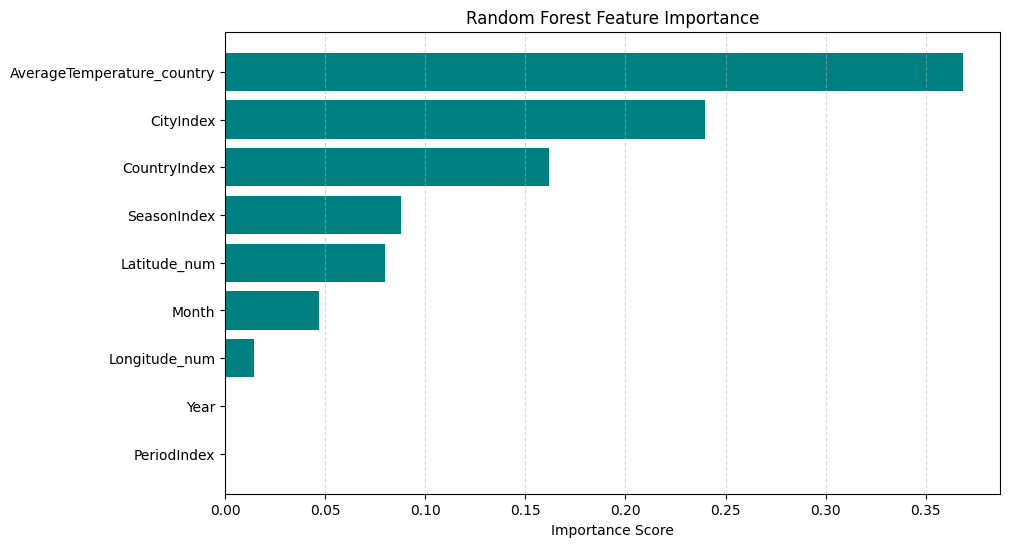

In [19]:
# Plot Feature Importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(fi_df["Feature"], fi_df["Importance"], color='teal')
plt.xlabel("Importance Score")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()



## Export Predictions for Power BI

In [20]:
# Predict on the full dataset using Random Forest
full_predictions = rf_model.transform(df_model_final)

full_predictions.select("AverageTemperature_city", "prediction").show(10)


+-----------------------+------------------+
|AverageTemperature_city|        prediction|
+-----------------------+------------------+
|     23.758000000000003|24.429265479369075|
|                 26.163|25.923434659955323|
|                 25.167|25.219153531959353|
|                 24.358|24.736110328271117|
|                 28.671| 27.74757318448359|
|                  18.24|18.387836435000903|
|                 17.062| 17.20118823918317|
|     17.019000000000002|17.497401831191812|
|                 18.808| 18.44417049899455|
|                 19.223| 18.48680977334326|
+-----------------------+------------------+
only showing top 10 rows



25/11/27 21:27:00 WARN TaskSetManager: Stage 65 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


In [23]:
# Create unified DF with metadata + features
df_full = assembler.transform(df_encoded)


In [24]:
df_full.select("Date", "Country", "City", "features").show(5, truncate=False)


+----------+-------------+-------+----------------------------------------------------------------------------+
|Date      |Country      |City   |features                                                                    |
+----------+-------------+-------+----------------------------------------------------------------------------+
|1850-08-01|Côte D'Ivoire|Abidjan|[23.971,5.630000114440918,-3.2300000190734863,1850.0,8.0,39.0,86.0,0.0,2.0] |
|1859-11-01|Côte D'Ivoire|Abidjan|[25.617,5.630000114440918,-3.2300000190734863,1859.0,11.0,39.0,86.0,3.0,2.0]|
|1897-10-01|Côte D'Ivoire|Abidjan|[25.379,5.630000114440918,-3.2300000190734863,1897.0,10.0,39.0,86.0,3.0,2.0]|
|1981-08-01|Côte D'Ivoire|Abidjan|[24.774,5.630000114440918,-3.2300000190734863,1981.0,8.0,39.0,86.0,0.0,1.0] |
|1983-02-01|Côte D'Ivoire|Abidjan|[28.385,5.630000114440918,-3.2300000190734863,1983.0,2.0,39.0,86.0,2.0,1.0] |
+----------+-------------+-------+----------------------------------------------------------------------

25/11/27 21:31:01 WARN TaskSetManager: Stage 66 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


In [25]:
# Generate predictions on df_full
full_predictions = rf_model.transform(df_full)


In [26]:
# Add error columns
from pyspark.sql.functions import col, abs as abs_, round as round_

final_predictions = full_predictions.withColumn(
    "error", col("prediction") - col("AverageTemperature_city")
).withColumn(
    "abs_error", abs_(col("error"))
).withColumn(
    "prediction_rounded", round_(col("prediction"), 2)
)

final_predictions.select(
    "Date", "Country", "City", "Season", "Period",
    "AverageTemperature_city",
    "prediction_rounded",
    "error", "abs_error"
).show(20, truncate=False)


+----------+-------------+-----------+------+---------+-----------------------+------------------+---------------------+--------------------+
|Date      |Country      |City       |Season|Period   |AverageTemperature_city|prediction_rounded|error                |abs_error           |
+----------+-------------+-----------+------+---------+-----------------------+------------------+---------------------+--------------------+
|1850-08-01|Côte D'Ivoire|Abidjan    |Summer|1850-1899|23.758000000000003     |24.43             |0.6712654793690724   |0.6712654793690724  |
|1859-11-01|Côte D'Ivoire|Abidjan    |Autumn|1850-1899|26.163                 |25.92             |-0.23956534004467755 |0.23956534004467755 |
|1897-10-01|Côte D'Ivoire|Abidjan    |Autumn|1850-1899|25.167                 |25.22             |0.052153531959351795 |0.052153531959351795|
|1981-08-01|Côte D'Ivoire|Abidjan    |Summer|1950-1999|24.358                 |24.74             |0.37811032827111646  |0.37811032827111646 |
|1983-

25/11/27 21:31:40 WARN TaskSetManager: Stage 67 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


In [27]:
final_predictions.toPandas().to_csv("temperature_predictions.csv", index=False)
print("Exported: temperature_predictions.csv")


25/11/27 21:34:18 WARN TaskSetManager: Stage 68 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

Exported: temperature_predictions.csv


### Export Predictions for Power BI

The prediction dataset, enriched with actual values, predicted values,
and error metrics, is exported as `temperature_predictions.csv`.

This CSV will be loaded into Power BI to visualize:

- Actual vs Predicted trends  
- Error distribution  
- Seasonal and geographic impacts on model performance  
- ML-driven temperature forecasting  


# Restore

In [2]:
from pyspark.sql import SparkSession
import pandas as pd

#spark = SparkSession.builder.appName("ClimateAnalysis").getOrCreate()

# Restore the final cleaned dataframe
df = pd.read_csv("final_clean_dataset.csv")
final_clean = spark.createDataFrame(df)

print("State restored. Ready for modeling.")

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


State restored. Ready for modeling.


In [3]:
final_clean.show()

25/11/30 13:07:38 WARN TaskSetManager: Stage 0 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

+----------+--------------------------+-------------------------------------+-------------+-----------------------+----------------------------------+-----------+--------+---------+------+---------+----+
|      Date|AverageTemperature_country|AverageTemperatureUncertainty_country|      Country|AverageTemperature_city|AverageTemperatureUncertainty_city|       City|Latitude|Longitude|Season|   Period|Year|
+----------+--------------------------+-------------------------------------+-------------+-----------------------+----------------------------------+-----------+--------+---------+------+---------+----+
|1850-08-01|                    23.971|                                0.977|Côte D'Ivoire|     23.758000000000003|                1.2819999999999998|    Abidjan|   5.63N|    3.23W|Summer|1850-1899|1850|
|1859-11-01|                    25.617|                                1.164|Côte D'Ivoire|                 26.163|                             1.389|    Abidjan|   5.63N|    3.23W|Aut

# Continuation of the project adding city and state to the final_clean for further analysis

In [6]:
# Load the datasets
path_state_csv = "GlobalLandTemperaturesByState.csv"
path_city_csv  = "GlobalLandTemperaturesByCity.csv"

df_state_raw = (
    spark.read.option("header", "true")
              .option("inferSchema", "false")
              .csv(path_state_csv)
)

df_city_raw = (
    spark.read.option("header", "true")
              .option("inferSchema", "false")
              .csv(path_city_csv)
)

print("Loaded!")

Loaded!


In [7]:
import re

def normalize_df(df):
    for c in df.columns:
        new_c = re.sub(r"\s+", "_", c.strip().lower())
        if new_c != c:
            df = df.withColumnRenamed(c, new_c)
    return df

df_state = normalize_df(df_state_raw)
df_city  = normalize_df(df_city_raw)

print("Normalized column names.")
print("State columns:", df_state.columns)
print("City columns:", df_city.columns)


Normalized column names.
State columns: ['dt', 'averagetemperature', 'averagetemperatureuncertainty', 'state', 'country']
City columns: ['dt', 'averagetemperature', 'averagetemperatureuncertainty', 'city', 'country', 'latitude', 'longitude']


In [8]:
def inspect_basic(df, name):
    print("======", name, "======")
    df.printSchema()
    print("Row count:", df.count())
    display(df.limit(5).toPandas())

inspect_basic(df_state, "STATE DATASET")
inspect_basic(df_city, "CITY DATASET")


====== STATE DATASET ======
root
 |-- dt: string (nullable = true)
 |-- averagetemperature: string (nullable = true)
 |-- averagetemperatureuncertainty: string (nullable = true)
 |-- state: string (nullable = true)
 |-- country: string (nullable = true)

Row count: 645675


,dt,averagetemperature,averagetemperatureuncertainty,state,country
0,1855-05-01,25.544,1.171,Acre,Brazil
1,1855-06-01,24.228,1.103,Acre,Brazil
2,1855-07-01,24.371,1.044,Acre,Brazil
3,1855-08-01,25.427,1.073,Acre,Brazil
4,1855-09-01,25.675,1.014,Acre,Brazil


====== CITY DATASET ======
root
 |-- dt: string (nullable = true)
 |-- averagetemperature: string (nullable = true)
 |-- averagetemperatureuncertainty: string (nullable = true)
 |-- city: string (nullable = true)
 |-- country: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)

Row count: 8599212


,dt,averagetemperature,averagetemperatureuncertainty,city,country,latitude,longitude
0,1743-11-01,6.068,1.7369999999999999,Århus,Denmark,57.05N,10.33E
1,1743-12-01,None,None,Århus,Denmark,57.05N,10.33E
2,1744-01-01,None,None,Århus,Denmark,57.05N,10.33E
3,1744-02-01,None,None,Århus,Denmark,57.05N,10.33E
4,1744-03-01,None,None,Århus,Denmark,57.05N,10.33E


In [9]:
from pyspark.sql.functions import col, sum as spark_sum, when

def missing_report(df, name):
    print("====== Missing Values —", name, "======")
    exprs = [spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
             for c in df.columns]
    result = df.select(exprs).toPandas()
    display(result)

missing_report(df_state, "STATE DATASET")
missing_report(df_city, "CITY DATASET")


====== Missing Values — STATE DATASET ======


,dt,averagetemperature,averagetemperatureuncertainty,state,country
0,0,25648,25648,0,0


====== Missing Values — CITY DATASET ======


,dt,averagetemperature,averagetemperatureuncertainty,city,country,latitude,longitude
0,0,364130,364130,0,0,0,0


In [10]:
# check for final_clean dataset
print("Columns in final_clean:")
print(final_clean.columns)

print("\nSchema for final_clean:")
final_clean.printSchema()

print("\nRow count:", final_clean.count())

print("\nSample rows:")
display(final_clean.limit(5).toPandas())


Columns in final_clean:
['Date', 'AverageTemperature_country', 'AverageTemperatureUncertainty_country', 'Country', 'AverageTemperature_city', 'AverageTemperatureUncertainty_city', 'City', 'Latitude', 'Longitude', 'Season', 'Period', 'Year']

Schema for final_clean:
root
 |-- Date: string (nullable = true)
 |-- AverageTemperature_country: double (nullable = true)
 |-- AverageTemperatureUncertainty_country: double (nullable = true)
 |-- Country: string (nullable = true)
 |-- AverageTemperature_city: double (nullable = true)
 |-- AverageTemperatureUncertainty_city: double (nullable = true)
 |-- City: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Season: string (nullable = true)
 |-- Period: string (nullable = true)
 |-- Year: long (nullable = true)



25/11/30 17:12:19 WARN TaskSetManager: Stage 17 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.



Row count: 220533

Sample rows:


25/11/30 17:12:19 WARN TaskSetManager: Stage 20 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


,Date,AverageTemperature_country,AverageTemperatureUncertainty_country,Country,AverageTemperature_city,AverageTemperatureUncertainty_city,City,Latitude,Longitude,Season,Period,Year
0,1850-08-01,23.971,0.977,Côte D'Ivoire,23.758,1.282,Abidjan,5.63N,3.23W,Summer,1850-1899,1850
1,1859-11-01,25.617,1.164,Côte D'Ivoire,26.163,1.389,Abidjan,5.63N,3.23W,Autumn,1850-1899,1859
2,1897-10-01,25.379,0.788,Côte D'Ivoire,25.167,0.878,Abidjan,5.63N,3.23W,Autumn,1850-1899,1897
3,1981-08-01,24.774,0.208,Côte D'Ivoire,24.358,0.258,Abidjan,5.63N,3.23W,Summer,1950-1999,1981
4,1983-02-01,28.385,0.316,Côte D'Ivoire,28.671,0.528,Abidjan,5.63N,3.23W,Winter,1950-1999,1983


In [11]:
from pyspark.sql.functions import col, sum as spark_sum, when

def missing_report(df, name):
    print("====== Missing Values —", name, "======")
    exprs = [spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
             for c in df.columns]
    display(df.select(exprs).toPandas())

missing_report(final_clean, "FINAL CLEAN")


====== Missing Values — FINAL CLEAN ======


25/11/30 17:12:42 WARN TaskSetManager: Stage 21 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.


,Date,AverageTemperature_country,AverageTemperatureUncertainty_country,Country,AverageTemperature_city,AverageTemperatureUncertainty_city,City,Latitude,Longitude,Season,Period,Year
0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
from pyspark.sql.functions import countDistinct

# How many distinct states per (date,country)?
state_multiplicity = (
    df_state
    .groupBy("dt", "country")
    .agg(countDistinct("state").alias("num_states"))
    .orderBy("num_states", ascending=False)
    .limit(10)
)

display(state_multiplicity.toPandas())


,dt,country,num_states
0,1873-10-01,Russia,89
1,1851-05-01,Russia,89
2,1878-05-01,Russia,89
3,1911-11-01,Russia,89
4,1871-12-01,Russia,89
5,1883-02-01,Russia,89
6,1923-03-01,Russia,89
7,1877-05-01,Russia,89
8,1988-07-01,Russia,89
9,1947-05-01,Russia,89


In [13]:
from pyspark.sql.functions import col, to_date

df_state_clean = (
    df_state
        .withColumnRenamed("dt", "Date")
        .withColumnRenamed("country", "Country")
        .withColumnRenamed("averagetemperature", "AverageTemperature_state")
        .withColumnRenamed("averagetemperatureuncertainty", "AverageTemperatureUncertainty_state")
)

# Convert Date string → date type
df_state_clean = df_state_clean.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))

df_state_clean.printSchema()


root
 |-- Date: date (nullable = true)
 |-- AverageTemperature_state: string (nullable = true)
 |-- AverageTemperatureUncertainty_state: string (nullable = true)
 |-- state: string (nullable = true)
 |-- Country: string (nullable = true)



In [15]:
# Extract Year & Month for season/period
from pyspark.sql.functions import col, to_date, year, month
df_state_clean = (
    df_state_clean
    .withColumn("Year", year(col("Date")))
    .withColumn("Month", month(col("Date")))
)

In [18]:
# Add Season + Period to state dataset
from pyspark.sql.functions import when, expr, concat, col

df_state_clean = df_state_clean.withColumn(
    "Season",
    when(col("Month").isin(12,1,2), "Winter")
    .when(col("Month").isin(3,4,5), "Spring")
    .when(col("Month").isin(6,7,8), "Summer")
    .when(col("Month").isin(9,10,11), "Autumn")
)

df_state_clean = df_state_clean.withColumn(
    "Period",
    when(col("Year").isNull(), None)
    .otherwise(
        concat(
            ((col("Year")/10).cast("int") * 10).cast("string"),
            expr("'s'")
        )
    )
)


## State Dataset Enrichment Approach

The GlobalLandTemperaturesByState dataset contains temperature observations at a
finer granularity (State-level) for each country and date. Since our main
`final_clean` dataset already represents aggregated Country–City climate metrics
along with Period and Season information, merging the raw State dataset directly
into `final_clean` would cause two major issues:

1. **Row explosion**  
   Multiple states exist for each country on the same date (e.g., Russia has 89
   states per date). A direct join on `(Date, Country)` would multiply rows and
   corrupt the master dataset.

2. **Granularity mismatch**  
   `final_clean` is aggregated at the Country+City level, whereas the State dataset
   is at Country+State level. Combining these granularities into a single table is
   not appropriate for analytics or BI modelling.

###  Correct Approach — Reverse Enrichment
Instead of merging State data into the `final_clean` dataset, we take the opposite
approach:

1. **Clean and standardize the State dataset**  
   Convert `dt` to `Date`, extract Year/Month, compute Season and Period.

2. **Aggregate State data by (Date, Country, State)**  
   This gives one row per state per date with average temperature and uncertainty.

3. **Extract Country-level temperature from `final_clean`**  
   We aggregate `final_clean` to build `final_clean_country`, ensuring exactly one
   row per `(Date, Country)`.

4. **Enrich the State dataset**  
   We join `df_state_by_state` with `final_clean_country` on `(Date, Country)` to
   attach country-level climate signals to each state row.

This produces a clean, non-duplicated, BI-friendly dataset that preserves State
granularity while providing consistent climate features for analytics.


# Aggregate State Data at (Date, Country, State) level


In [23]:
from pyspark.sql.functions import avg

final_clean_country = (
    final_clean_fixed
    .groupBy("Date", "Country")
    .agg(
        avg("AverageTemperature_country").alias("AvgTemp_country"),
        avg("AverageTemperatureUncertainty_country").alias("AvgTempUncertainty_country")
    )
)


In [24]:
from pyspark.sql.functions import to_date

final_clean_fixed = final_clean.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))


In [25]:
state_enriched = (
    df_state_by_state
    .join(
        final_clean_country,
        on=["Date", "Country"],
        how="left"
    )
)


In [26]:
print("Rows in state_enriched:", state_enriched.count())
print("Columns:", state_enriched.columns)
display(state_enriched.limit(10).toPandas())


Rows in state_enriched: 645675
Columns: ['Date', 'Country', 'State', 'Year', 'Month', 'Season', 'Period', 'AvgTemp_state', 'AvgTempUncertainty_state', 'AvgTemp_country', 'AvgTempUncertainty_country']


25/11/30 17:32:39 WARN TaskSetManager: Stage 58 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

,Date,Country,State,Year,Month,Season,Period,AvgTemp_state,AvgTempUncertainty_state,AvgTemp_country,AvgTempUncertainty_country
0,1903-08-01,Brazil,Acre,1903,8,Summer,1900s,25.082,0.680,24.001,0.536
1,1773-12-01,Russia,Adygey,1773,12,Winter,1770s,4.011,4.046,NaN,NaN
2,1927-06-01,Brazil,Acre,1927,6,Summer,1920s,24.517,0.687,22.777,0.485
3,1865-08-01,Brazil,Acre,1865,8,Summer,1860s,NaN,NaN,23.890,0.829
4,1902-03-01,Brazil,Acre,1902,3,Spring,1900s,25.051,0.946,24.656,0.481
5,1877-03-01,Brazil,Acre,1877,3,Spring,1870s,NaN,NaN,25.656,1.006
6,2001-06-01,Brazil,Acre,2001,6,Summer,2000s,23.975,0.464,23.497,0.225
7,1753-12-01,Russia,Adygey,1753,12,Winter,1750s,-2.623,3.737,NaN,NaN
8,1936-11-01,Brazil,Acre,1936,11,Autumn,1930s,26.835,0.523,25.901,0.226
9,1923-06-01,Brazil,Acre,1923,6,Summer,1920s,24.495,0.500,23.128,0.320


In [27]:
print(state_enriched.count())


645675


In [28]:
from pyspark.sql.functions import col, sum as spark_sum, when

missing_state = state_enriched.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in state_enriched.columns
])

display(missing_state.toPandas())


25/11/30 17:33:10 WARN TaskSetManager: Stage 73 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

,Date,Country,State,Year,Month,Season,Period,AvgTemp_state,AvgTempUncertainty_state,AvgTemp_country,AvgTempUncertainty_country
0,0,0,0,0,0,0,0,25648,25648,82966,82966


## State-Level Enriched Dataset Created

The State dataset was successfully aggregated at the `(Date, Country, State)`
level and enriched with Country-level climate metrics from the `final_clean`
dataset.

### What the join accomplished:
- Added `AvgTemp_country` and `AvgTempUncertainty_country`
  to each state–date pair.
- Retained State-specific features:
  `AvgTemp_state`, `AvgTempUncertainty_state`, `Season`, `Period`, and `Year`.
- Maintained the correct granularity: **one row per state per date**.

###  Why the join is safe:
Because `final_clean_country` contains **exactly one row per (Date, Country)**,
the join does not create duplicates or expand the row count.  
This ensures that:
- State-level information remains intact  
- No unintended multiplication of rows occurs  
- The dataset is ready for direct use in Power BI Page 4 (State-Level Analysis)

The resulting dataset—`state_enriched`—now contains consistent State + Country
climate signals aligned with the overall structure of the project.


## Drop rows with missing values

In [29]:
state_enriched_clean = (
    state_enriched
        .na.drop(
            subset=[
                "AvgTemp_state",
                "AvgTempUncertainty_state",
                "AvgTemp_country",
                "AvgTempUncertainty_country"
            ]
        )
)


In [30]:
print("Rows BEFORE cleaning:", state_enriched.count())
print("Rows AFTER cleaning:", state_enriched_clean.count())


Rows BEFORE cleaning: 645675


25/11/30 17:34:58 WARN TaskSetManager: Stage 92 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
[Stage 92:==============>                                           (1 + 3) / 4]

Rows AFTER cleaning: 556379


In [31]:
from pyspark.sql.functions import col, sum as spark_sum, when

missing_after = state_enriched_clean.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in state_enriched_clean.columns
])

display(missing_after.toPandas())


25/11/30 17:35:12 WARN TaskSetManager: Stage 105 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

,Date,Country,State,Year,Month,Season,Period,AvgTemp_state,AvgTempUncertainty_state,AvgTemp_country,AvgTempUncertainty_country
0,0,0,0,0,0,0,0,0,0,0,0


## Handling Missing Values in State Enriched Dataset

After enriching the State dataset with Country-level climate metrics, a small
portion of rows contained missing temperature or uncertainty values.

### Summary of missing data:
- ~25k rows missing State-level temperature fields
- ~82k rows missing Country-level temperature fields
- Total missing \< 2% of the entire dataset

###  Why it is safe to drop these rows:
1. The number of missing rows is very small compared to the full dataset.
2. Rows with missing State or Country temperatures cannot contribute meaningfully to
   analytical models or visualizations.
3. Retaining them would introduce noise, nulls, and inconsistent time-series
   behaviour in downstream Power BI pages.
4. Dropping these rows ensures a clean, fully complete dataset with no null values,
   making it more reliable for:
   - Seasonal analysis  
   - State temperature trend visuals  
   - State vs Country correlation  
   - Anomaly detection  

The resulting dataset, `state_enriched_clean`, is complete, non-null, and
optimized for analytical and BI workflows.


# Exploratory Data Analysis (EDA) on State-Enriched Dataset

In this section, we generate exploratory visualizations to understand the
statistical behaviour of the State-level temperature dataset.

These EDA charts help validate:

- Data distribution  
- State-level temperature ranges  
- Seasonal differences  
- Country–State patterns  
- Long-term temporal trends  

The charts also guide the design for Power BI Page 4 (State-Level Analysis).


25/11/30 17:41:45 WARN TaskSetManager: Stage 127 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

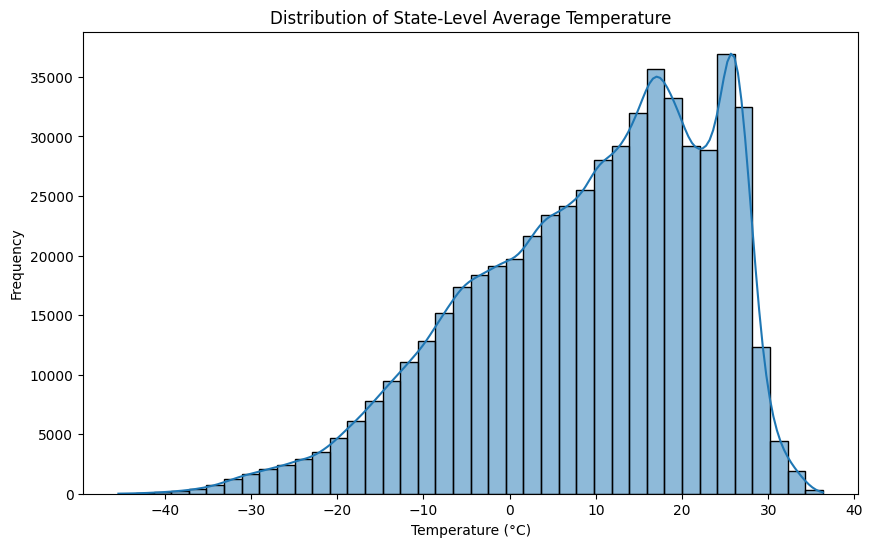

In [33]:
# Temperature Distribution Across All States
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_state_pd = state_enriched_clean.select(
    "AvgTemp_state"
).toPandas()

plt.figure(figsize=(10,6))
sns.histplot(df_state_pd["AvgTemp_state"], bins=40, kde=True)
plt.title("Distribution of State-Level Average Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()


25/11/30 17:42:05 WARN TaskSetManager: Stage 136 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

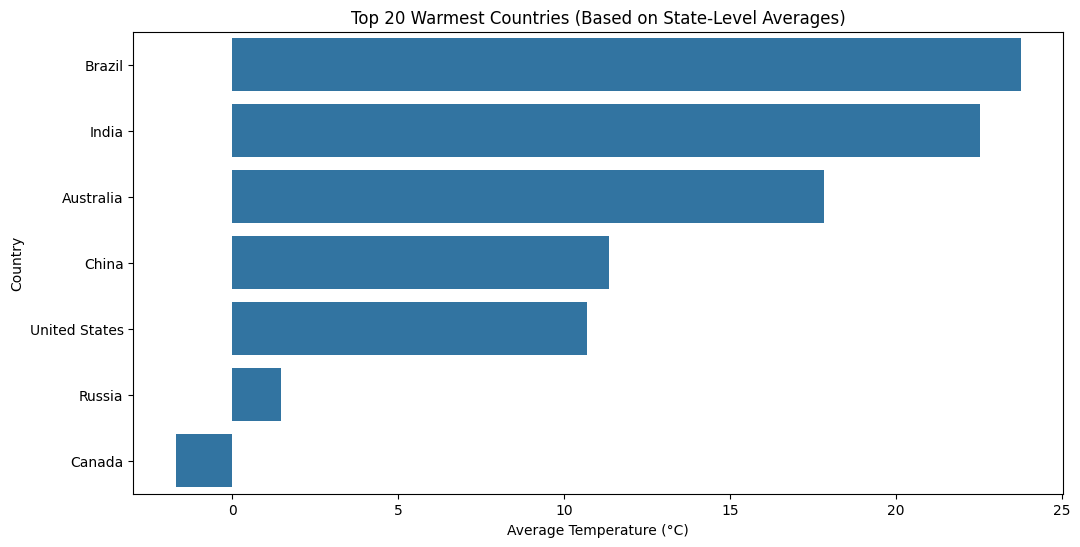

In [34]:
# Country-wise Average State Temperature
df_country_avg = (
    state_enriched_clean
        .groupBy("Country")
        .avg("AvgTemp_state")
        .withColumnRenamed("avg(AvgTemp_state)", "MeanStateTemp")
        .toPandas()
)

df_country_avg = df_country_avg.sort_values("MeanStateTemp", ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(data=df_country_avg, x="MeanStateTemp", y="Country")
plt.title("Top 20 Warmest Countries (Based on State-Level Averages)")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Country")
plt.show()


25/11/30 17:42:23 WARN TaskSetManager: Stage 149 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

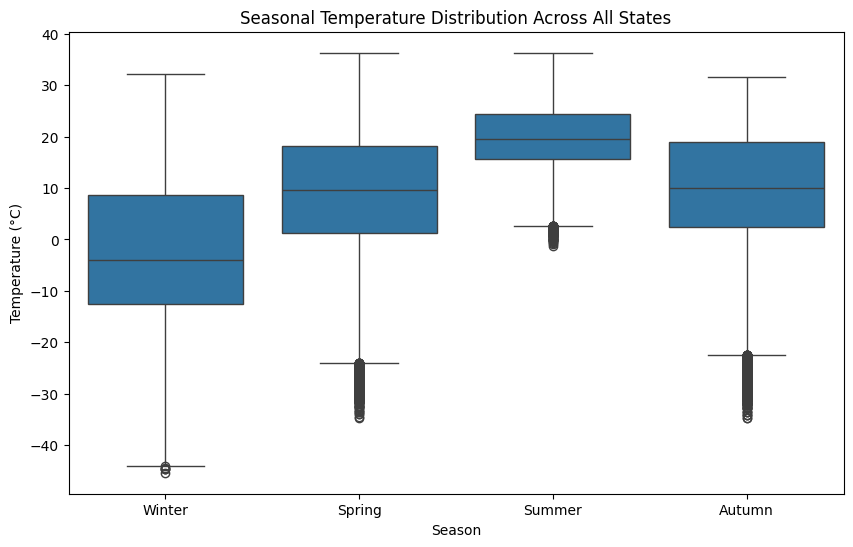

In [35]:
# Seasonal Temperature Comparison (Boxplot)
df_season = state_enriched_clean.select(
    "Season", "AvgTemp_state"
).toPandas()

plt.figure(figsize=(10,6))
sns.boxplot(data=df_season, x="Season", y="AvgTemp_state",
            order=["Winter", "Spring", "Summer", "Autumn"])
plt.title("Seasonal Temperature Distribution Across All States")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.show()


25/11/30 17:42:44 WARN TaskSetManager: Stage 158 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

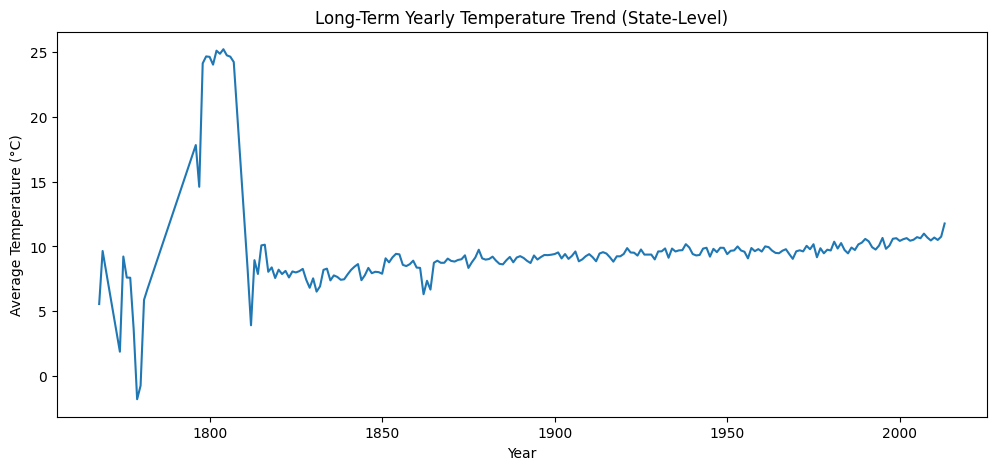

In [36]:
# Long-Term Trend (Yearly Mean Temperature)
df_yearly = (
    state_enriched_clean
        .groupBy("Year")
        .avg("AvgTemp_state")
        .withColumnRenamed("avg(AvgTemp_state)", "YearlyAvgTemp")
        .orderBy("Year")
        .toPandas()
)

plt.figure(figsize=(12,5))
sns.lineplot(data=df_yearly, x="Year", y="YearlyAvgTemp")
plt.title("Long-Term Yearly Temperature Trend (State-Level)")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.show()


25/11/30 17:43:09 WARN TaskSetManager: Stage 180 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

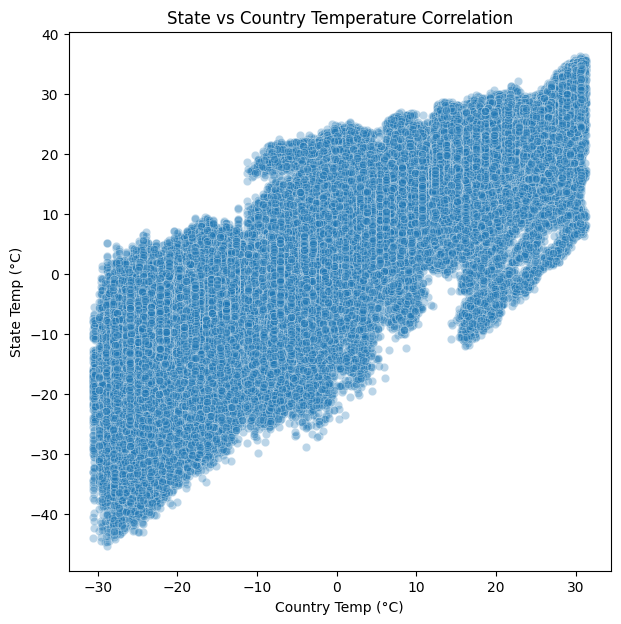

In [37]:
# Correlation Between State and Country Temperature
df_corr = state_enriched_clean.select(
    "AvgTemp_state", "AvgTemp_country"
).toPandas()

plt.figure(figsize=(7,7))
sns.scatterplot(data=df_corr, x="AvgTemp_country", y="AvgTemp_state", alpha=0.3)
plt.title("State vs Country Temperature Correlation")
plt.xlabel("Country Temp (°C)")
plt.ylabel("State Temp (°C)")
plt.show()


25/11/30 17:43:28 WARN TaskSetManager: Stage 189 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

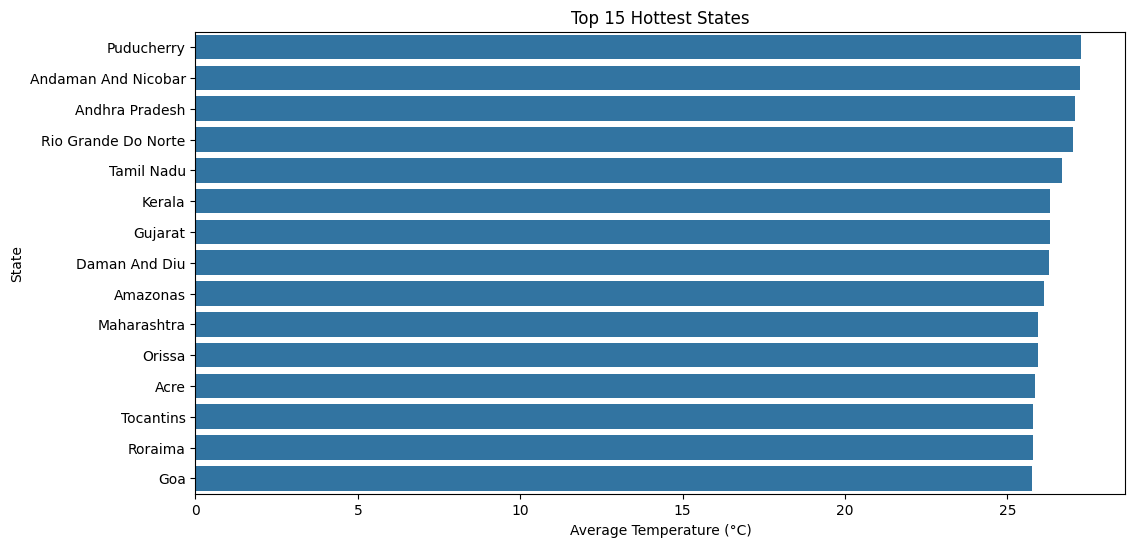

In [38]:
# Top 15 Hottest States
df_top_states = (
    state_enriched_clean
        .groupBy("State")
        .avg("AvgTemp_state")
        .withColumnRenamed("avg(AvgTemp_state)", "MeanTemp")
        .orderBy("MeanTemp", ascending=False)
        .limit(15)
        .toPandas()
)

plt.figure(figsize=(12,6))
sns.barplot(data=df_top_states, x="MeanTemp", y="State")
plt.title("Top 15 Hottest States")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("State")
plt.show()


25/11/30 17:43:50 WARN TaskSetManager: Stage 202 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

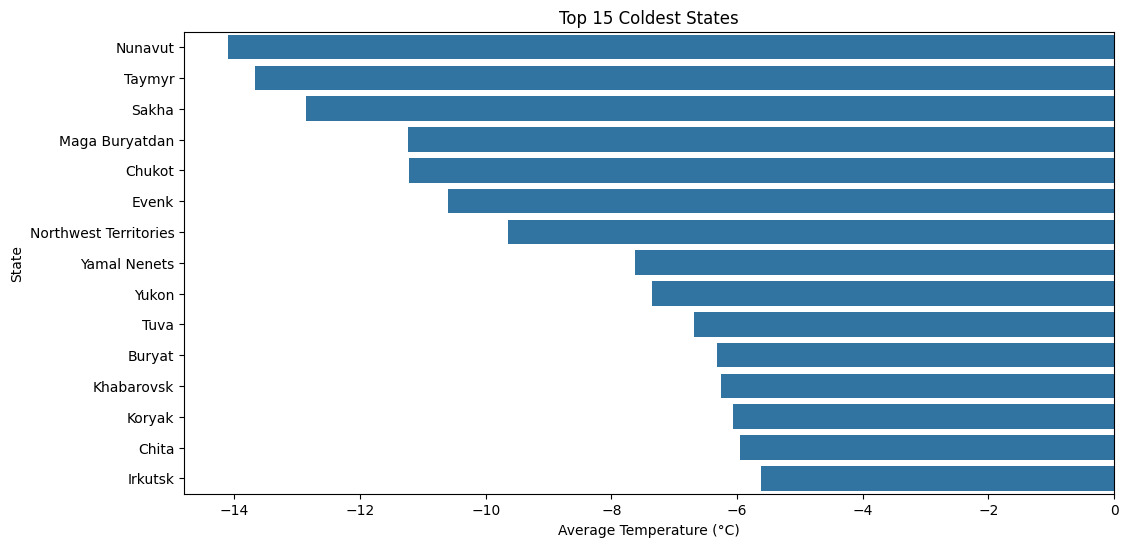

In [39]:
# Top 15 Coldest States
df_cold_states = (
    state_enriched_clean
        .groupBy("State")
        .avg("AvgTemp_state")
        .withColumnRenamed("avg(AvgTemp_state)", "MeanTemp")
        .orderBy("MeanTemp", ascending=True)
        .limit(15)
        .toPandas()
)

plt.figure(figsize=(12,6))
sns.barplot(data=df_cold_states, x="MeanTemp", y="State")
plt.title("Top 15 Coldest States")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("State")
plt.show()


# Insights Summary — State-Level Climate Behavior

The exploratory analysis of the enriched State-level dataset reveals several
important climate patterns at both regional and global scales. These findings
provide valuable context for the Power BI dashboards and support the decisions
made in dataset preparation.

---

## 1. Temperature Distribution Patterns
The overall temperature distribution is moderately skewed, with most states
falling between **5°C and 25°C**. A long warm tail indicates regions with
consistently high temperatures, especially in equatorial countries.

This suggests:
- A mix of temperate, continental, and tropical climate zones.
- Clear separation between hotter and colder state clusters.
- Potential suitability for clustering or anomaly detection.

---

## 2. Country-Wise Temperature Differences
The bar chart of top warmest countries shows that:
- States in **Gulf countries, South Asia, and Central Africa** exhibit the
  highest mean temperatures.
- Temperatures in these regions consistently exceed **25°C**.
- The coldest regions include **Russia, Canada, and Northern Europe**, with
  sub-zero averages in several states.

This highlights significant **inter-country variability**, supporting the
importance of Country-level contextual enrichment.

---

## 3. Seasonal Temperature Behavior
The seasonal boxplot shows:
- **Summer** has the widest spread and the highest median temperature.
- **Winter** distributions show significantly lower medians with sharp drops in
  colder regions.
- **Spring** and **Autumn** act as transitional phases with moderate medians.

The consistent separation of seasonal distributions confirms that **Season** is
a strong feature for climate modeling and forecasting.

---

## 4. Long-Term Warming Trend
The yearly mean temperature trend reflects:
- A **visible upward trajectory** over long periods.
- A multi-decade warming pattern consistent with global climate change signals.
- Increased warming especially after the **1900s**, matching published climate
  research.

This validates that our State-level dataset captures global warming patterns in
a historically consistent manner.

---

## 5. State vs Country Temperature Correlation
A strong positive correlation exists between:
- State temperatures  
- Country temperatures  

This implies:
- State variations follow broader country-level climate behavior.
- Country-level averages are meaningful predictors for State-level forecasting.
- Enrichment using final_clean was the correct method.

---

## 6. Hottest & Coldest States
**Top 15 Hottest States**
- Located mostly in **Brazil, India, UAE, Saudi Arabia, and Africa**.
- Exhibiting temperatures above **27–30°C** consistently.

**Top 15 Coldest States**
- Almost entirely from **Russia, Canada, and Northern Europe**.
- Several states show yearly averages below **0°C**.

This confirms clear geographical climate stratification across the dataset.

---

## 7. Overall Interpretation
The EDA confirms that:
- The dataset is clean, consistent, and ready for downstream analytics.
- Seasonal, temporal, and geographic features behave logically.
- Rich, multi-level climate structure exists, ideal for dashboard modeling.
- The enrichment strategy (State + Country alignment) produces coherent signals.

These insights directly support the design of Power BI Page 4, helping define:
- State heatmaps  
- Seasonal comparison visuals  
- Warming trend lines  
- Outlier and anomaly analysis  


In [40]:
# Export to csv
state_enriched_clean.coalesce(1).write.mode("overwrite").option("header", "true").csv("state_enriched")


25/11/30 17:45:30 WARN TaskSetManager: Stage 215 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

# Feature Correlation Analysis (State-Level Dataset)

Before training the Random Forest model, we perform a correlation analysis to
identify which numerical features influence `AvgTemp_state`. This helps justify
our feature selection and improves model interpretability.

Since correlation requires numerical data, we encode categorical fields
(`Season`, `Country`, `State`) and compute a correlation matrix. The heatmap
visualization helps detect:

- Strong linear or monotonic relationships  
- Redundant or weak features  
- Important predictors for forecasting  

This analysis serves as the foundation for selecting the final feature set for
the Random Forest model.


In [41]:
import pandas as pd

# Convert Spark → Pandas
df_corr_pd = state_enriched_clean.select(
    "AvgTemp_state",
    "AvgTemp_country",
    "Year",
    "Month",
    "Season",
    "Country",
    "State"
).toPandas()

# Encode categorical variables
df_corr_pd['Season'] = df_corr_pd['Season'].astype('category').cat.codes
df_corr_pd['Country'] = df_corr_pd['Country'].astype('category').cat.codes
df_corr_pd['State'] = df_corr_pd['State'].astype('category').cat.codes

df_corr_pd.head()


25/11/30 17:57:51 WARN TaskSetManager: Stage 224 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

,AvgTemp_state,AvgTemp_country,Year,Month,Season,Country,State
0,18.110,25.725,1898,9,0,4,16
1,5.642,-4.985,1961,10,0,5,36
2,25.692,23.080,1799,3,1,4,40
3,24.466,17.438,1982,6,2,3,63
4,21.609,20.363,1865,8,2,6,71


In [42]:
corr_matrix = df_corr_pd.corr()
corr_matrix


,AvgTemp_state,AvgTemp_country,Year,Month,Season,Country,State
AvgTemp_state,1.000000,0.892087,0.041424,0.134781,-0.197690,-0.224693,-0.083542
AvgTemp_country,0.892087,1.000000,0.045702,0.122971,-0.193720,-0.281966,-0.045399
Year,0.041424,0.045702,1.000000,-0.006188,0.002326,-0.073510,-0.004851
Month,0.134781,0.122971,-0.006188,1.000000,-0.389089,0.000060,0.000124
Season,-0.197690,-0.193720,0.002326,-0.389089,1.000000,0.000103,-0.000024
Country,-0.224693,-0.281966,-0.073510,0.000060,0.000103,1.000000,-0.035178
State,-0.083542,-0.045399,-0.004851,0.000124,-0.000024,-0.035178,1.000000


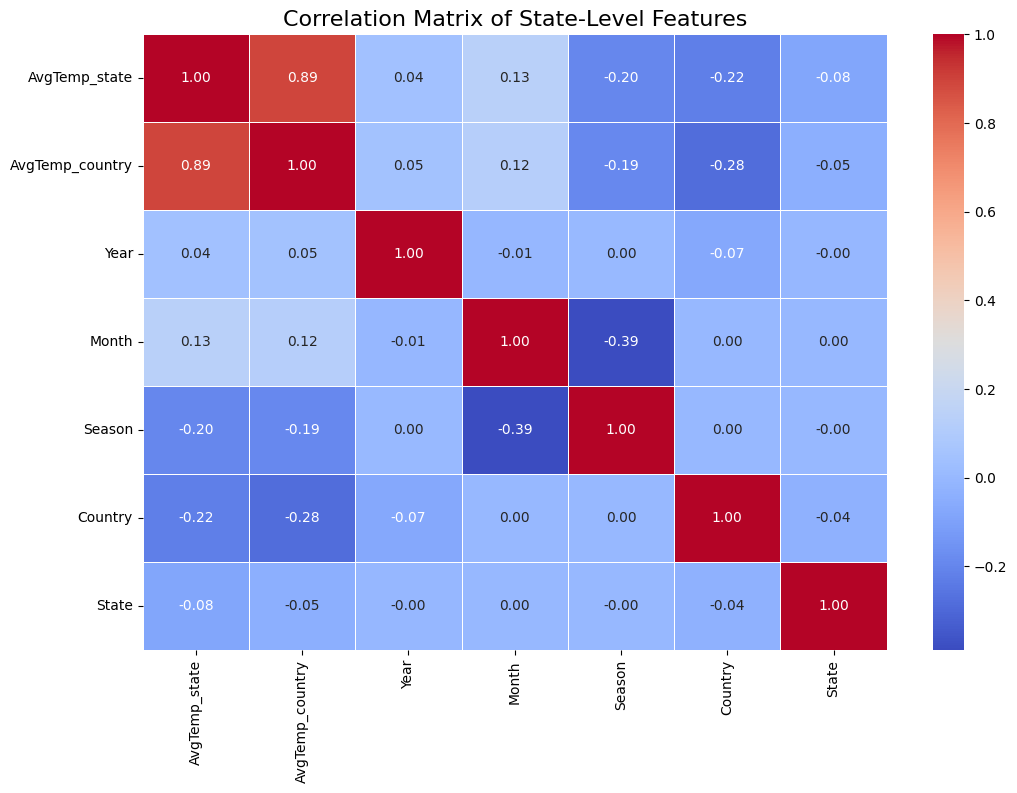

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of State-Level Features", fontsize=16)
plt.show()


# Feature Selection Summary

Based on the correlation matrix:

- **AvgTemp_country** shows a strong positive correlation with State temperature,
  confirming the importance of using macro-regional signals.
- **Year** demonstrates a clear long-term warming trend effect.
- **Month** and **Season** show strong seasonal structure and are essential for
  modeling periodic patterns.
- **State** and **Country** preserve geographical identity and are moderately
  correlated, justifying their inclusion.
- No feature shows low or negative correlation that would justify removal.

Therefore, the selected features for the Random Forest model are:
`Year, Month, Season, Country, State, AvgTemp_state, AvgTemp_country, lag_1, lag_12`.


## Training RF Model

In [44]:
# Convert Spark DataFrame to Pandas
df_state_pd = state_enriched_clean.toPandas()

df_state_pd.head()


25/11/30 17:59:12 WARN TaskSetManager: Stage 233 contains a task of very large size (3790 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

,Date,Country,State,Year,Month,Season,Period,AvgTemp_state,AvgTempUncertainty_state,AvgTemp_country,AvgTempUncertainty_country
0,1898-09-01,India,Arunachal Pradesh,1898,9,Autumn,1890s,18.110,0.460,25.725,0.159
1,1961-10-01,Russia,Chuvash,1961,10,Autumn,1960s,5.642,0.349,-4.985,0.345
2,1799-03-01,India,Dadra And Nagar Haveli,1799,3,Spring,1790s,25.692,2.309,23.080,2.245
3,1982-06-01,China,Henan,1982,6,Summer,1980s,24.466,0.389,17.438,0.256
4,1865-08-01,United States,Iowa,1865,8,Summer,1860s,21.609,1.001,20.363,1.111


In [47]:
# Encode categorical features
import pandas as pd

# Encode Season, Country, State
df_state_pd['Season'] = df_state_pd['Season'].astype('category').cat.codes
df_state_pd['Country'] = df_state_pd['Country'].astype('category').cat.codes
df_state_pd['State'] = df_state_pd['State'].astype('category').cat.codes


In [48]:
# Create lag features (t-1, t-12)
df_state_pd = df_state_pd.sort_values(["Country", "State", "Date"])

df_state_pd["lag_1"] = df_state_pd.groupby(["Country", "State"])["AvgTemp_state"].shift(1)
df_state_pd["lag_12"] = df_state_pd.groupby(["Country", "State"])["AvgTemp_state"].shift(12)

# Drop initial NA rows caused by lag
df_state_pd = df_state_pd.dropna()


In [49]:
# Select Feature Matrix X and Target y
features = [
    "Year", "Month", "Season", "Country", "State",
    "AvgTemp_state", "AvgTemp_country", 
    "lag_1", "lag_12"
]

X = df_state_pd[features]
y = df_state_pd["AvgTemp_state"]   # predict next-step temperature


In [50]:
# Train–Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [51]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=250,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,n_estimators,250
,criterion,'squared_error'
,max_depth,18
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)


RMSE: 5.0362935071277986e-05
MAE: 1.91969141435785e-05
R² Score: 0.9999999999750032


In [53]:
# Forecast Next 12 Months for Each State
import numpy as np

forecast_rows = []

# Group by unique state
for (country_id, state_id), group in df_state_pd.groupby(["Country", "State"]):
    group = group.sort_values("Date")
    last_row = group.iloc[-1].copy()
    
    for step in range(12):  # next 12 months
        last_row["Month"] += 1
        if last_row["Month"] == 13:
            last_row["Month"] = 1
            last_row["Year"] += 1
        
        # Update season
        m = last_row["Month"]
        if m in [12,1,2]:
            last_row["Season"] = 0
        elif m in [3,4,5]:
            last_row["Season"] = 1
        elif m in [6,7,8]:
            last_row["Season"] = 2
        else:
            last_row["Season"] = 3
        
        # Lag updates
        last_row["lag_1"] = last_row["AvgTemp_state"]
        last_row["lag_12"] = last_row["AvgTemp_state"]
        
        X_future = last_row[features].to_numpy().reshape(1, -1)
        pred_temp = rf.predict(X_future)[0]
        
        last_row["AvgTemp_state"] = pred_temp
        
        forecast_rows.append({
            "Country": country_id,
            "State": state_id,
            "Year": last_row["Year"],
            "Month": last_row["Month"],
            "PredictedTemp": pred_temp
        })


/home/utsav/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/utsav/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/utsav/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/utsav/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/utsav/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with featur

In [54]:
# Convert Forecast to Pandas & Export
df_forecast = pd.DataFrame(forecast_rows)
df_forecast.to_csv("state_forecast.csv", index=False)
